# Preguntarle a FilmAffinity

### ¿Puede un LLM de 3.000 millones de parámetros hablar de cine con lo que dicen los espectadores, citarlos y no inventar?

Grupo Tango:
- Gustavo Betancur
- Mike Martinez
- Pedro Jojoa
- Juan Sebastian Orozco

**Sesión 5 — Retrieval-Augmented Generation, Ollama y ChatBots** · MIIA, Universidad Icesi

---

| Sección | Contenido |
|---|---|
| 1 | El problema, por qué RAG, la propuesta y seis hipótesis |
| 2 | Andamiaje: entorno, Ollama, figuras y cronómetro |
| 3 | EDA: el catálogo, las críticas que entran y lo que no dicen (figuras 01–02) |
| 4 | De críticas a fragmentos: dos fallos del guía, tres troceados y una cabecera (figura 03) |
| 5 | Un banco de 450 preguntas que se corrige solo |
| 6 | **Recuperación: decisiones en dev y la escalera en test, desde el guía hasta el reranker** (figuras 04–06) |
| 7 | El espacio de embeddings, con y sin cabecera (figura 07) |
| 8 | **Generación: alucinación medida, abstención y citas** (figuras 08–09) |
| 9 | CineRAG: demo con memoria e interfaz Gradio |
| 10 | Costes, veredicto y conclusiones |

**Qué hacemos.** Construimos **CineRAG**, un chatbot que responde preguntas sobre películas con las
críticas de usuarios de FilmAffinity del corpus de las Sesiones 2–4 y con las fichas de cada película, y
que cita cada afirmación con la fuente de la que sale. El generador es `llama3.2:3b` servido con
Ollama, como en el guía. Lo demás (troceado, índice, recuperación, filtros, compuerta de abstención e
interfaz) lo construimos y lo **medimos pieza a pieza** contra la línea base del guía.

**Por qué este corpus, otra vez.** En la Sesión 4 intentamos meter las críticas *en los pesos*:
afinamos GPT-2 con un token de control y aprendió a escribir críticas, pero no la que se le pedía
(QWK 0,05). RAG es la apuesta contraria: no se le enseña nada al modelo, se le **da a leer** lo que
necesita en el momento de responder. Es el mismo corpus visto desde la otra orilla.

---

## 1. El problema

### 1.1 La tarea

Un espectador que pregunta *"¿vale la pena Joker?"*, *"¿por qué Avatar divide tanto?"* o *"busco una
de supervivencia en la nieve, basada en hechos reales"* no quiere la opinión del modelo: quiere saber
qué dicen **los que la vieron**, y poder comprobar de dónde sale cada cosa. Distinguimos cuatro tipos
de pregunta, porque cada uno pone a prueba una pieza distinta:

| Tipo | Ejemplo | Qué necesita |
|---|---|---|
| **Opinión** sobre una película con nombre | ¿Qué opinan los espectadores de *Joker*? | encontrar las críticas **de esa** película, y varias, no una |
| **Aspecto** concreto de una película | ¿Qué dicen de la música de *Interstellar*? | encontrar **el fragmento** que habla de eso |
| **Trama**: descubrir sin saber el título | Busco una de supervivencia en la nieve basada en hechos reales | buscar por significado, en sinopsis y críticas |
| **Fuera del catálogo** | ¿Qué tal es *El relojero de Mompox*? (no existe) | **no inventar** |

### 1.2 Por qué no basta el modelo solo

La clase teórica clasifica los fallos de un LLM en alucinaciones de **memoria** y de **razonamiento**,
y añade dos carencias estructurales: **no tiene fuentes** con las que contrastar y su conocimiento es
**estático**. Las tres aparecen aquí y las tres se pueden medir:

- **Memoria.** Le preguntamos a `llama3.2:3b` quién dirigió una película que no existe y respondió con
  un nombre, sin dudar. En §8.2 medimos con qué frecuencia acierta el director de películas que sí
  existen, y si falla más en las menos conocidas.
- **Sin fuentes.** Aunque acierte, no puede decir *qué* espectador opina eso. Una respuesta sobre
  opiniones sin atribución no se puede verificar.
- **Estático.** `llama3.2` se entrenó con datos hasta diciembre de 2023. En §3.4 contamos qué parte
  de las críticas del catálogo se escribió después.

### 1.3 Por qué este corpus es difícil para un RAG

El guía usa Wikihow, que es casi el caso ideal. FilmAffinity no lo es, y cada diferencia pide una pieza:

| | Wikihow (guía) | FilmAffinity (aquí) | Pieza que lo resuelve |
|---|---|---|---|
| ¿De qué habla el fragmento? | de lo que dice el título del artículo | **dos de cada tres críticas no nombran la película** (§3.4) | cabecera contextual (§4.2) |
| ¿Cuál es la respuesta? | una, informativa | una **distribución** de opiniones, a veces opuestas | una fuente por crítica, MMR y filtro por nota (§6) |
| ¿Cómo se busca? | por significado | por significado **y** por nombres propios (títulos, directores) | búsqueda híbrida BM25 + E5 (§6) |
| ¿Qué tipo de texto? | instrucciones | opinión, ironía, **spoilers** | spoilers indexados aparte y filtrados (§4) |
| ¿Qué documentos? | uno | **ficha** estructurada + **críticas** libres | dos tipos de documento en el mismo índice |

### 1.4 La propuesta

```
pregunta ─► reformulación con el historial (LLM) ─► router: ¿película?  ¿nota?  ¿spoilers?
                                                          │
            ┌─────────────────────────────────────────────┘ filtros
            ▼
  BM25 (léxico) ─┐
                 ├─► fusión RRF ─► reranker cross-encoder ─► 1 por crítica + MMR ─► k fuentes
  E5 (denso)  ───┘                        │
                                          └─► compuerta: si la mejor fuente es irrelevante, no se llama al LLM
                                                          │
                    prompt con [1]…[k] ─► llama3.2:3b ─► respuesta con citas [n] ─► lista de fuentes con enlace
```

| Pieza | Guía | Aquí | Por qué |
|---|---|---|---|
| Documentos | artículo troceado | ficha + crítica + spoiler | tres usos distintos; el spoiler se filtra |
| Fragmento | texto suelto | **cabecera contextual** (película, año, director, nota) + texto | 2 de cada 3 críticas no nombran la película |
| Encoder | E5 **sin** prefijos | E5 con `query:` / `passage:` | así fue entrenado E5 (§6.1) |
| Búsqueda | producto punto | híbrida BM25 + E5 (RRF) y **reranker** | los títulos son léxicos; el matiz es semántico |
| Filtros | — | **router** por película, nota y spoilers | preguntas sobre una película concreta |
| Diversidad | — | **una fuente por crítica** + **MMR** | cinco trozos de la misma crítica no son cinco opiniones |
| Memoria | definida pero rota (§4.1) | reformulación de la pregunta con el historial | preguntas de seguimiento |
| Abstención | instrucción en el *prompt* | instrucción + **compuerta** por relevancia | §8.3 mide si la instrucción basta |
| Citas | títulos al final, a veces mal atribuidos (§4.1) | `[n]` en el texto + fuente con enlace | verificable |
| Evaluación | una pregunta, a ojo | banco de 450 preguntas, dev/test, *bootstrap* | §5 |

### 1.5 Cómo se mide

| Pregunta | Instrumento | Dónde |
|---|---|---|
| ¿Recupera lo que debe? | Hit@k, MRR@10 y P@5 sobre un banco de preguntas con respuesta conocida | §5, §6 |
| ¿Qué aporta cada pieza? | la **escalera**: se añade una pieza cada vez, desde la réplica del guía | §6.6 |
| ¿Inventa sin RAG? ¿Y con RAG? | acierto del director, a libro cerrado y con RAG, por popularidad | §8.2 |
| ¿Sabe callarse? | tasa de abstención ante películas inventadas y de respuesta ante reales | §8.3 |
| ¿Cita bien? | citas presentes, válidas y de la película preguntada | §8.4 |

Las decisiones (troceado, encoder, umbral de la compuerta) se toman sobre la mitad **dev** del banco y
las cifras finales se leen sobre la mitad **test**, que se toca una vez. Cada métrica lleva su ruido
por remuestreo de preguntas.

### 1.6 Hipótesis

Escritas antes de ejecutar, cada una con el criterio que la decide. La celda de §10.2 calcula el
veredicto a partir de las variables.

> **H1 — La cabecera contextual es el escalón más grande.** En preguntas de *opinión*, añadir la
> cabecera sube la P@5 en al menos 0,20 y es el mayor salto de toda la escalera.
>
> **H2 — El guía pierde por no usar los prefijos de E5.** Añadirlos mejora la métrica principal por
> encima del ruido (más de dos desviaciones de la diferencia pareada) en al menos dos de las tres familias.
>
> **H3 — Léxico y semántico se complementan.** La búsqueda híbrida supera a la mejor de sus dos partes
> en al menos dos familias, y el reranker añade encima en la familia *aspecto*, la más fina.
>
> **H4 — Sin RAG el modelo inventa fichas, y más en la cola larga.** A libro cerrado, `llama3.2:3b`
> acierta el director en menos de la mitad de las películas, y en el quintil más popular acierta al
> menos 0,25 más que en el menos popular. Con RAG acierta ≥ 0,85 en todos los quintiles.
>
> **H5 — Con RAG, el tamaño del generador importa menos.** La brecha de acierto entre `llama3.2:1b` y
> `3b` se reduce a menos de la mitad al pasar de libro cerrado a RAG.
>
> **H6 — Una instrucción no basta para abstenerse; una compuerta sí.** Ante películas inventadas, el RAG
> con la instrucción *"si no sabes, dilo"* se abstiene en menos del 50 % de los casos; con la compuerta
> del reranker, en el 90 % o más, sin dejar de responder a más del 10 % de las preguntas legítimas.

---

## 2. Andamiaje

### 2.1 Entorno y presupuesto

`S5_HUMO=1` reduce el presupuesto al mínimo para una prueba de humo que recorre el notebook en unos
minutos. Con el presupuesto real, la primera corrida tarda unos 45 minutos en una GPU de 8 GB (la
mayor parte son *embeddings* y llamadas al LLM). Todo lo caro se guarda en `cache/`, así que las
corridas siguientes tardan unos pocos minutos.

In [1]:
import os, re, sys, ast, math, time, json, random, hashlib, warnings, unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

HUMO = os.environ.get("S5_HUMO") == "1"

# Presupuesto
N_PELICULAS = 500     # catálogo: 5 quintiles de popularidad × 100 películas
N_RESENAS   = 12      # críticas por película como máximo: las más votadas como útiles
N_PREG      = 150     # preguntas por familia en el banco de evaluación
N_CAND      = 20      # candidatos que reordena el reranker
N_BOOT      = 1000    # remuestreos para el ruido de cada métrica
if HUMO:
    N_PELICULAS, N_RESENAS, N_PREG, N_BOOT = 50, 4, 20, 100

MODELO_LLM = "llama3.2:3b"      # el generador
MODELO_PEQ = "llama3.2:1b"      # §8.2: ¿cuánto modelo hace falta si el conocimiento viene del contexto?
NUM_CTX  = 8192                 # ventana de contexto explícita para Ollama
MAX_TOKENS = 512                # tope de tokens por respuesta (§2.3)
ENCODERS = {"small": "intfloat/multilingual-e5-small",
            "base":  "intfloat/multilingual-e5-base",
            "large": "intfloat/multilingual-e5-large"}
ENCODER  = "large"              # el del guía; §6.4 compara los tres tamaños
RERANKER = "BAAI/bge-reranker-v2-m3"
MMR_LAMBDA = 0.7                # fijado antes de mirar; §6.5 lo pone a prueba

DATA  = Path(os.environ.get("S5_DATA", "data"))
FIGS  = Path("figuras");    FIGS.mkdir(exist_ok=True)
RES   = Path("resultados"); RES.mkdir(exist_ok=True)
CACHE = Path("cache");      CACHE.mkdir(exist_ok=True)
SUFIJO = "-humo" if HUMO else ""

print(f"colab={IN_COLAB}   semilla={SEED}   dispositivo={DEVICE}   humo={HUMO}")
print(f"catálogo: {N_PELICULAS} películas × ≤{N_RESENAS} críticas   banco: {N_PREG} preguntas por familia")
print(f"generador: {MODELO_LLM} (y {MODELO_PEQ})   encoder: {ENCODERS[ENCODER]}   reranker: {RERANKER}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("AVISO: sin GPU los embeddings y el LLM serán muy lentos. En Colab, usa un entorno con GPU T4.")

colab=False   semilla=42   dispositivo=cuda   humo=False
catálogo: 500 películas × ≤12 críticas   banco: 150 preguntas por familia
generador: llama3.2:3b (y llama3.2:1b)   encoder: intfloat/multilingual-e5-large   reranker: BAAI/bge-reranker-v2-m3
GPU: NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB)


In [2]:
def asegurar(paquetes):
    # Instala en Colab lo que falte; en local avisa y no toca el entorno.
    faltan = []
    for modulo, pip in paquetes:
        try:
            __import__(modulo)
        except ImportError:
            faltan.append(pip)
    if faltan:
        if IN_COLAB:
            print(f"instalando: {' '.join(faltan)}…")
            get_ipython().run_line_magic("pip", "install -q " + " ".join(faltan))
        else:
            raise SystemExit(f"Faltan dependencias: pip install {' '.join(faltan)}")

asegurar([("sentence_transformers", "sentence-transformers"), ("faiss", "faiss-cpu"),
          ("gradio", "gradio"), ("ollama", "ollama"), ("sklearn", "scikit-learn")])

import sentence_transformers, transformers, gradio, ollama, faiss
print(f"torch {torch.__version__}   transformers {transformers.__version__}   "
      f"sentence-transformers {sentence_transformers.__version__}   gradio {gradio.__version__}")

torch 2.11.0+cu128   transformers 5.19.0   sentence-transformers 6.1.0   gradio 6.30.0


### 2.2 Estilo de las figuras y cronómetro

El de las entregas anteriores: azul para magnitudes, naranja para lo que señala el texto, gris claro
para la referencia. El cronómetro es el de la Sesión 3: acumula lo que cuesta cada paso, y en §10.1
sirve para comparar el coste de cada pieza con lo que aporta.

In [3]:
AZUL, NARANJA = "#2a78d6", "#eb6834"
AZUL_CLARO, NARANJA_CLARO = "#9cc2f0", "#f5b496"
TINTA, TINTA_2, MALLA = "#0b0b0b", "#52514e", "#e4e3df"
GRIS_REAL = "#b9b7b1"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 10, "font.family": "DejaVu Sans",
    "axes.edgecolor": MALLA, "axes.linewidth": 1.0,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": MALLA, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def limpiar(ax, ejes=("top", "right")):
    for e in ejes:
        ax.spines[e].set_visible(False)
    return ax

def guardar(fig, nombre):
    fig.savefig(FIGS / f"{nombre}.png")
    return fig

COLOR_QUINTIL = [mpl.colormaps["Blues"](v) for v in (0.35, 0.5, 0.65, 0.8, 0.95)]

CRONO = []

class medir:
    # Context manager que acumula cuánto costó cada paso.
    def __init__(self, etiqueta):
        self.etiqueta = etiqueta
    def __enter__(self):
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *exc):
        self.seg = time.perf_counter() - self.t0
        CRONO.append({"paso": self.etiqueta, "segundos": self.seg})
        total = sum(c["segundos"] for c in CRONO)
        print(f"   ⏱  {self.etiqueta}: {self.seg/60:.1f} min   (acumulado {total/60:.1f} min)")
        return False

### 2.3 Ollama

En Colab, el guía instala Ollama y pide abrir una terminal (`xterm`) para lanzar `ollama serve`. Aquí el
servidor se lanza como subproceso desde la propia celda, así que el notebook corre de principio a fin
sin pasos manuales. En local basta con tener Ollama abierto.

La clase `LLM` es la del guía. `Ollama` cambia cuatro cosas:

1. **Temperatura 0 y semilla fija.** Los experimentos de §8 tienen que poder repetirse.
2. **`num_ctx` explícito.** Ollama recorta sin avisar lo que no cabe en su ventana por defecto. Con seis
   fuentes y el *prompt* de sistema rondamos los 2.000 tokens, así que fijamos 8.192 para no depender
   de la versión instalada.
3. **Un tope de 512 tokens por respuesta.** Ollama no corta por defecto (`num_predict = -1`). En la
   prueba de humo, una pregunta sobre una película inventada metió a `llama3.2:3b` en un bucle a
   temperatura 0: generó más de **80.000 tokens**, desplazando su propio contexto, hasta que paramos el
   notebook. Es el bucle de la decodificación voraz que vimos en la Sesión 4, ahora en un modelo de 3B.
4. **Memoria en disco.** Con temperatura 0 la salida no cambia, así que se guarda: una segunda corrida
   del notebook no repite las cientos de llamadas de §5 y §8. Lo mismo para las puntuaciones del
   reranker (§6).

In [4]:
import shutil, subprocess

def ollama_vivo():
    try:
        ollama.list()
        return True
    except Exception:
        return False

if IN_COLAB and shutil.which("ollama") is None:
    print("instalando Ollama…")
    subprocess.run("apt-get -qq install -y zstd > /dev/null && curl -fsSL https://ollama.com/install.sh | sh > /dev/null",
                   shell=True, check=True)
if not ollama_vivo():
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(60):
        time.sleep(1)
        if ollama_vivo():
            break
assert ollama_vivo(), "Ollama no responde: ábrelo (o ejecuta `ollama serve` en una terminal) y repite la celda."

instalados = {m.model for m in ollama.list().models}
for m in (MODELO_LLM, MODELO_PEQ):
    if m not in instalados:
        print(f"descargando {m}…")
        ollama.pull(m)
print("Ollama listo:", sorted({m.model for m in ollama.list().models} & {MODELO_LLM, MODELO_PEQ}))

Ollama listo: ['llama3.2:1b', 'llama3.2:3b']


In [5]:
from abc import abstractmethod
from typing import Generator

class LLM:
    # La interfaz del guía: un generador de tokens y una versión que los junta.
    @abstractmethod
    def completion_stream(self, messages, **opciones) -> Generator[str, None, None]:
        raise NotImplementedError

    def completion(self, messages, **opciones) -> str:
        return "".join(self.completion_stream(messages, **opciones))


MEMO_LLM = CACHE / f"llm{SUFIJO}.json"
MEMO_RR  = CACHE / f"reranker{SUFIJO}.json"
_memo    = json.loads(MEMO_LLM.read_text(encoding="utf-8")) if MEMO_LLM.exists() else {}
_memo_rr = json.loads(MEMO_RR.read_text(encoding="utf-8")) if MEMO_RR.exists() else {}

def guardar_memo():
    MEMO_LLM.write_text(json.dumps(_memo, ensure_ascii=False), encoding="utf-8")
    MEMO_RR.write_text(json.dumps(_memo_rr), encoding="utf-8")


class Ollama(LLM):

    def __init__(self, model, **opciones):
        self.model = model
        self.opciones = {"temperature": 0, "seed": SEED, "num_ctx": NUM_CTX, "num_predict": MAX_TOKENS, **opciones}
        self.stats = []

    def completion_stream(self, messages, **opciones):
        if isinstance(messages, str):
            messages = [{"role": "user", "content": messages}]
        t0 = time.perf_counter()
        for chunk in ollama.chat(model=self.model, messages=messages, stream=True,
                                 options={**self.opciones, **opciones}):
            yield chunk.message.content or ""
            if chunk.done:
                self.stats.append({"modelo": self.model, "segundos": time.perf_counter() - t0,
                                   "tokens_prompt": chunk.prompt_eval_count or 0,
                                   "tokens_salida": chunk.eval_count or 0,
                                   "seg_generacion": (chunk.eval_duration or 0) / 1e9})

    def completion(self, messages, memo=True, **opciones):
        if isinstance(messages, str):
            messages = [{"role": "user", "content": messages}]
        clave = hashlib.sha1(json.dumps([self.model, messages, {**self.opciones, **opciones}],
                                        ensure_ascii=False, sort_keys=True).encode()).hexdigest()
        if memo and clave in _memo:
            return _memo[clave]
        texto = super().completion(messages, **opciones)
        if memo:
            _memo[clave] = texto
        return texto


llm, llm_peq = Ollama(MODELO_LLM), Ollama(MODELO_PEQ)
with medir("calentar el LLM"):
    print(llm.completion("Responde solo con la palabra: listo.", memo=False))

listo.
   ⏱  calentar el LLM: 0.0 min   (acumulado 0.0 min)


---

## 3. El corpus

### 3.1 Descarga y limpieza

[`naim-prog/filmaffinity-reviews-info`](https://huggingface.co/datasets/naim-prog/filmaffinity-reviews-info)
(licencia MIT), el mismo de las Sesiones 2–4, pero esta vez con sus **dos** tablas: las críticas de
usuarios y la **ficha** de cada película (dirección, reparto, género, sinopsis, nota media, votos,
plataformas). Las sesiones anteriores sólo usaban la primera.

Las críticas tienen un campo que no habíamos mirado: **`author_review_spoiler`**, la parte que el autor
marcó como *spoiler* y que FilmAffinity oculta por defecto. La indexamos aparte para poder filtrarla.

In [6]:
import urllib.request

BASE_HUB = "https://huggingface.co/datasets/naim-prog/filmaffinity-reviews-info/resolve/main/"
FUENTES = {"criticas": "film_reviews.parquet", "peliculas": "film_info.parquet"}
DATA.mkdir(parents=True, exist_ok=True)
for nombre, archivo in FUENTES.items():
    destino = DATA / f"{nombre}.parquet"
    if not destino.exists():
        print(f"descargando {nombre}…")
        urllib.request.urlretrieve(BASE_HUB + archivo, destino)


def limpiar_texto(s):
    if not isinstance(s, str):
        return ""
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def lista(s):
    # Las columnas de lista vienen como texto: "['Drama', 'Thriller']".
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
    except (ValueError, SyntaxError):
        return []
    return [str(x).strip() for x in v] if isinstance(v, (list, tuple)) else []

def norm(s):
    # minúsculas, sin tildes ni puntuación: para comparar títulos y buscar palabras
    s = unicodedata.normalize("NFKD", str(s).lower()).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9]+", " ", s).strip()

def norm_caso(s):
    # igual, pero conservando las mayúsculas (§6.1: títulos de una sola palabra)
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return re.sub(r"[^A-Za-z0-9]+", " ", s).strip()


COLS = ["film_id", "review_id", "author_id", "author_rating", "author_review_title", "author_review_desc",
        "author_review_spoiler", "author_users_useful", "author_review_date_year"]
criticas = pd.read_parquet(DATA / "criticas.parquet", columns=COLS)
criticas = criticas[criticas.author_review_desc.fillna("").str.strip().str.len() > 0].reset_index(drop=True)

peliculas = pd.read_parquet(DATA / "peliculas.parquet")
for c in ["film_movie_types", "film_director", "film_cast", "film_genre", "film_where_to_watch_sus"]:
    peliculas[c] = peliculas[c].map(lista)
peliculas["n_resenas"] = peliculas.film_id.map(criticas.groupby("film_id").size()).fillna(0).astype(int)

print(f"fichas: {len(peliculas):,}   con al menos una crítica: {(peliculas.n_resenas > 0).sum():,}")
print(f"críticas con texto: {len(criticas):,}   de {criticas.author_id.nunique():,} autores   "
      f"({criticas.author_review_date_year.min()}–{criticas.author_review_date_year.max()})")
print(f"críticas con sección de spoiler: {criticas.author_review_spoiler.notna().mean():.1%}")
print(f"\ncolumnas de la ficha: {', '.join(peliculas.columns)}")

fichas: 24,369   con al menos una crítica: 15,549
críticas con texto: 419,827   de 55,148 autores   (2005–2025)
críticas con sección de spoiler: 19.8%

columnas de la ficha: film_id, film_year, film_duration, film_title, film_original_title, film_movie_types, film_country, film_director, film_screenwriter, film_cast, film_music, film_cinematography, film_producer, film_genre, film_synospsis, film_average_rating, film_number_of_ratings, film_pro_reviews_positive, film_pro_reviews_neutral, film_pro_reviews_negative, film_where_to_watch_sus, film_where_to_watch_buy, film_where_to_watch_ren, n_resenas


### 3.2 El catálogo

Indexar 420.000 críticas no cabe en el presupuesto de una sesión, y tampoco hace falta para medir. El
catálogo son **500 películas**, elegidas para que la popularidad quede repartida, porque §8.2 necesita
comparar películas conocidas con películas de la cola larga:

1. Sólo largometrajes (fuera series, miniseries, episodios y TV) con **al menos 20 críticas**: para que
   haya opiniones de las que hablar.
2. Cinco **quintiles de popularidad** por número de votos en FilmAffinity, y 100 películas al azar de
   cada uno.
3. Las siete películas de la demo del video (§9) entran siempre, cada una en su quintil, en lugar de
   una elegida al azar.

In [7]:
FUERA = {"Serie", "Miniserie", "TV", "Episodio", "Mediometraje", "Cortometraje"}
cand = peliculas[peliculas.film_movie_types.map(lambda t: not (set(t) & FUERA))
                 & (peliculas.n_resenas >= 20)].copy()
cand["quintil"] = pd.qcut(cand.film_number_of_ratings.rank(method="first"), 5, labels=False).astype(int) + 1

DEMO = [("Joker", 2019), ("Interstellar", 2014), ("Parásitos", 2019), ("Oppenheimer", 2023),
        ("Pulp Fiction", 1994), ("Avatar", 2009), ("¡Viven!", 1993)]
es_demo = pd.Series(False, index=cand.index)
for t, a in DEMO:
    es_demo |= (cand.film_title == t) & (cand.film_year == a)

partes = []
for q, g in cand.groupby("quintil"):
    fijas = g[es_demo.loc[g.index]]
    resto = g.drop(fijas.index).sample(N_PELICULAS // 5 - len(fijas), random_state=SEED)
    partes.append(pd.concat([fijas, resto]))
catalogo = (pd.concat(partes).sort_values("film_number_of_ratings", ascending=False)
              .reset_index(drop=True))
P = catalogo.set_index("film_id")

print(f"candidatas: {len(cand):,} largometrajes con ≥ 20 críticas   →   catálogo: {len(catalogo)}")
print(f"demo: {es_demo.sum()} de {len(DEMO)} encontradas\n")
tabla = catalogo.groupby("quintil").agg(
    peliculas=("film_id", "size"),
    votos_min=("film_number_of_ratings", "min"), votos_max=("film_number_of_ratings", "max"),
    nota_mediana=("film_average_rating", "median"), criticas_mediana=("n_resenas", "median"))
tabla["ejemplos"] = catalogo.groupby("quintil").film_title.agg(lambda s: " · ".join(s.head(3)))
print(tabla.to_string())

candidatas: 3,924 largometrajes con ≥ 20 críticas   →   catálogo: 500
demo: 7 de 7 encontradas

         peliculas  votos_min  votos_max  nota_mediana  criticas_mediana                                                                                              ejemplos
quintil                                                                                                                                                                       
1              100        906       3003           5.9              26.0                                              Pura formalidad · Mejor otro día · La vendedora de rosas
2              100       3019       5450           6.2              36.0                                           Vivir dos veces · Dragon Ball Super: Broly · Velvet Buzzsaw
3              100       5499      11128           6.1              55.5  La crónica francesa (del Liberty, Kansas Evening Sun) · Posesión infernal: El despertar · Sin rodeos
4              100      11129

### 3.3 Las críticas que entran

De cada película entran como máximo las **12 críticas que más usuarios votaron como útiles**. Es la
curaduría que ya hace la comunidad de FilmAffinity y deja un catálogo de unas 6.000 críticas. Pero un
criterio de selección es un sesgo posible: la figura compara la distribución de notas de las críticas
elegidas con la de todas las críticas de esas mismas películas.

Medimos también la longitud en tokens del tokenizador de E5, porque E5 lee **como mucho 512**: lo que
pase de ahí se pierde si se indexa la crítica entera.

In [8]:
sel = criticas[criticas.film_id.isin(catalogo.film_id)]
resenas = (sel.sort_values(["film_id", "author_users_useful", "review_id"], ascending=[True, False, True])
              .groupby("film_id").head(N_RESENAS).reset_index(drop=True))
resenas["titulo_critica"] = resenas.author_review_title.map(limpiar_texto)
resenas["cuerpo"] = resenas.author_review_desc.map(limpiar_texto)
resenas["spoiler"] = resenas.author_review_spoiler.map(limpiar_texto)
# Muchas "secciones de spoiler" son firmas con el enlace a un blog: por debajo de 15 palabras se descartan.
resenas.loc[resenas.spoiler.str.split().str.len().fillna(0) < 15, "spoiler"] = ""
resenas["quintil"] = resenas.film_id.map(P.quintil)
resenas["palabras"] = resenas.cuerpo.str.split().str.len()

from transformers import AutoTokenizer
tok_e5 = AutoTokenizer.from_pretrained(ENCODERS[ENCODER])
tok_e5.model_max_length = 10**6          # sólo contamos: que no avise por pasar de 512
resenas["tokens"] = [len(x) for x in tok_e5(resenas.cuerpo.tolist(), add_special_tokens=False)["input_ids"]]

print(f"críticas en el catálogo: {len(resenas):,} de {len(sel):,} disponibles   "
      f"({resenas.groupby('film_id').size().mean():.1f} por película)")
print(f"con sección de spoiler útil: {(resenas.spoiler != '').mean():.1%}")
print(f"palabras por crítica: mediana {resenas.palabras.median():.0f}, p90 {resenas.palabras.quantile(.9):.0f}")
print(f"tokens E5 por crítica: mediana {resenas.tokens.median():.0f}, "
      f"pasan de 512: {(resenas.tokens > 512).mean():.1%}   "
      f"(fertilidad {resenas.tokens.sum() / resenas.palabras.sum():.2f} tokens por palabra)")
print(f"nota media: todas las críticas de estas películas {sel.author_rating.mean():.2f}   "
      f"las elegidas {resenas.author_rating.mean():.2f}")

críticas en el catálogo: 6,000 de 45,197 disponibles   (12.0 por película)
con sección de spoiler útil: 21.6%
palabras por crítica: mediana 229, p90 494
tokens E5 por crítica: mediana 322, pasan de 512: 26.0%   (fertilidad 1.42 tokens por palabra)
nota media: todas las críticas de estas películas 6.54   las elegidas 5.96


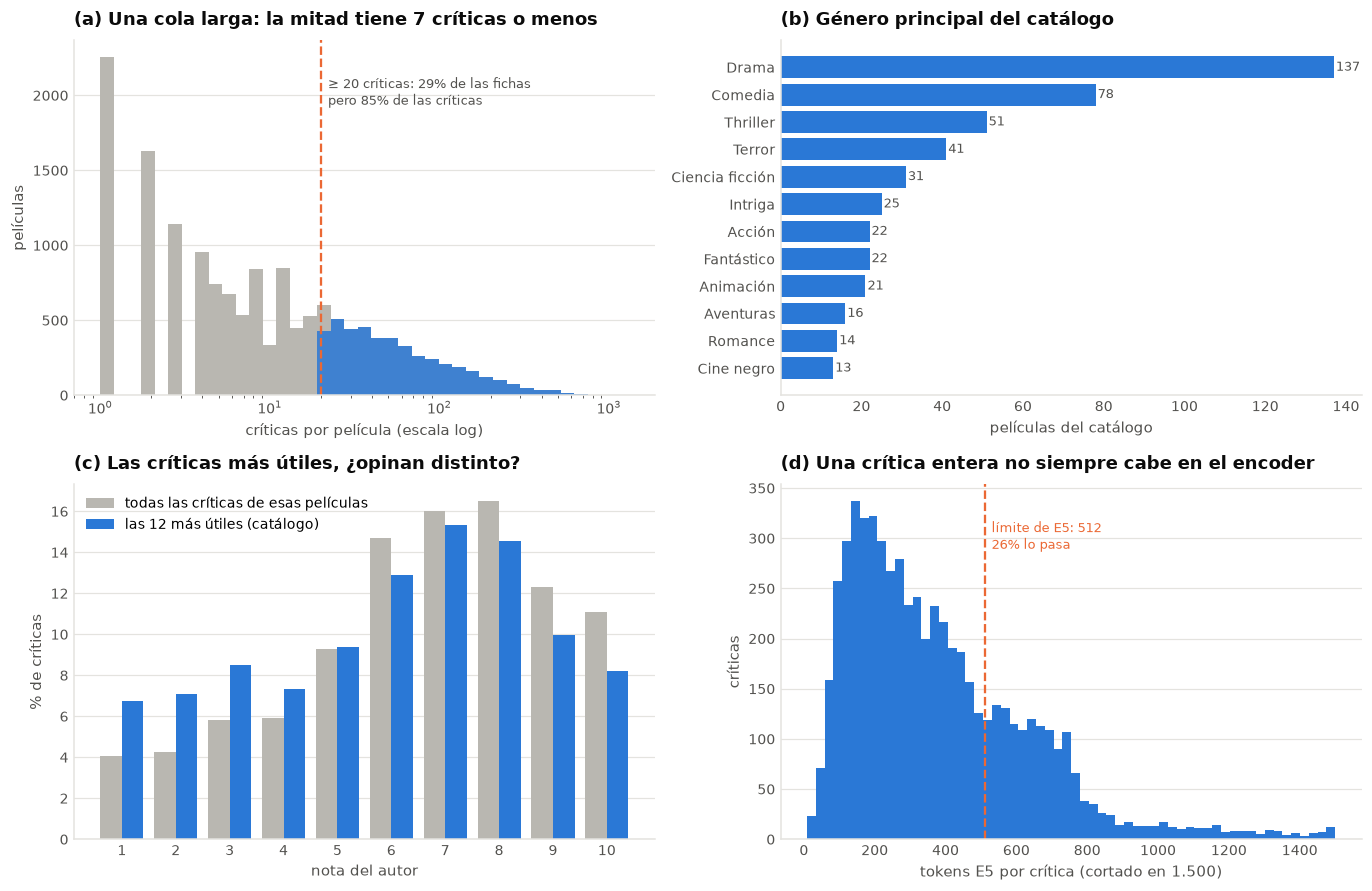

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12.6, 8.2))

# (a) críticas por película en todo el corpus
ax = axs[0, 0]
n = peliculas.n_resenas[peliculas.n_resenas > 0]
bins = np.logspace(0, np.log10(n.max() + 1), 40)
ax.hist(n, bins=bins, color=GRIS_REAL)
ax.hist(n[n >= 20], bins=bins, color=AZUL, alpha=.85)
ax.axvline(20, color=NARANJA, lw=1.5, ls="--")
ax.set_xscale("log")
ax.text(22, ax.get_ylim()[1] * .9, f"≥ 20 críticas: {(n >= 20).mean():.0%} de las fichas\n"
        f"pero {criticas.film_id.map(peliculas.set_index('film_id').n_resenas).ge(20).mean():.0%} de las críticas",
        fontsize=8.5, color=TINTA_2, va="top")
ax.set_xlabel("críticas por película (escala log)"); ax.set_ylabel("películas")
ax.set_title(f"(a) Una cola larga: la mitad tiene {n.median():.0f} críticas o menos")
ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)

# (b) géneros del catálogo
ax = axs[0, 1]
gen = catalogo.film_genre.map(lambda g: g[0] if g else "sin dato").value_counts().head(12)[::-1]
ax.barh(gen.index, gen.values, color=AZUL)
for i, v in enumerate(gen.values):
    ax.text(v + .5, i, str(v), va="center", fontsize=8.5, color=TINTA_2)
ax.set_xlabel("películas del catálogo")
ax.set_title("(b) Género principal del catálogo")
limpiar(ax)

# (c) notas: todas vs elegidas
ax = axs[1, 0]
x = np.arange(1, 11)
todas = sel.author_rating.value_counts(normalize=True).reindex(x, fill_value=0) * 100
elegidas = resenas.author_rating.value_counts(normalize=True).reindex(x, fill_value=0) * 100
ax.bar(x - .2, todas, width=.4, color=GRIS_REAL, label="todas las críticas de esas películas")
ax.bar(x + .2, elegidas, width=.4, color=AZUL, label="las 12 más útiles (catálogo)")
ax.set_xticks(x); ax.set_xlabel("nota del autor"); ax.set_ylabel("% de críticas")
ax.set_title("(c) Las críticas más útiles, ¿opinan distinto?")
ax.legend(loc="upper left"); ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)

# (d) longitud en tokens de E5
ax = axs[1, 1]
ax.hist(resenas.tokens.clip(upper=1500), bins=60, color=AZUL)
ax.axvline(512, color=NARANJA, lw=1.5, ls="--")
ax.text(530, ax.get_ylim()[1] * .9, f"límite de E5: 512\n{(resenas.tokens > 512).mean():.0%} lo pasa",
        fontsize=8.5, color=NARANJA, va="top")
ax.set_xlabel("tokens E5 por crítica (cortado en 1.500)"); ax.set_ylabel("críticas")
ax.set_title("(d) Una crítica entera no siempre cabe en el encoder")
ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)

plt.tight_layout(); guardar(fig, "01-corpus"); plt.show()

**Lo que vimos.** La cola es larga: la mitad de las películas del corpus tiene 7 críticas o menos. Pero
las que tienen 20 o más, el 29 % de las fichas, concentran el 85 % de las críticas, así que el umbral deja
fuera poco texto. El catálogo final tiene 6.000 críticas, 12 por película, de las 45.197 que había de
esas 500 películas. Drama, comedia y thriller son casi la mitad.

El panel (c) trae lo que no esperábamos: **las críticas más votadas como útiles son más negativas** que
el resto. La nota media baja de 6,54 a 5,96 y las notas de 1 a 4 pasan de ser una de cada cinco
críticas a ser casi una de cada tres. La comunidad premia la crítica que discrepa y argumenta. Para un
chatbot de opiniones es un sesgo a tener presente: si sólo resumiera estas doce, cualquier película
parecería peor valorada de lo que está. Por eso la ficha, con la nota media de FilmAffinity, entra
siempre como fuente (§8.1), y el modelo tiene con qué contrastar.

En el panel (d), una de cada cuatro críticas (26 %) pasa de los 512 tokens que lee E5, a 1,42 tokens por
palabra. Indexarlas enteras pierde su final.

### 3.4 Lo que las críticas no dicen

Tres comprobaciones que justifican piezas de la propuesta antes de construir nada:

- **¿Nombran la película?** Si una crítica no dice de qué película habla, un fragmento suyo indexado
  "pelado" no se puede encontrar preguntando por el título. Es la razón de la cabecera contextual.
- **¿Cuándo se escribieron?** Lo posterior a diciembre de 2023 no pudo estar en el entrenamiento de
  `llama3.2`: es el conocimiento estático de la clase teórica, en cifras.
- **¿Opinan lo mismo?** La dispersión de notas por película dice cuánto se pierde si el chatbot resume
  "la opinión" con una sola crítica.

In [10]:
def variantes_titulo(p):
    # título sin paréntesis y título original, normalizados; los de menos de 4 letras no se buscan
    vs = {norm(re.sub(r"\(.*?\)", "", p.film_title)), norm(p.film_original_title or "")}
    return [v for v in vs if len(v) >= 4]

VAR = {f: variantes_titulo(p) for f, p in P.iterrows()}
def menciona(texto, film_id):
    t = f" {norm(texto)} "
    return any(f" {v} " in t for v in VAR[film_id])

resenas["menciona_titulo"] = [menciona(f"{a} {b}", f) for a, b, f in
                              zip(resenas.titulo_critica, resenas.cuerpo, resenas.film_id)]
tardias = sel.author_review_date_year >= 2024
var_nota = sel.groupby("film_id").author_rating.std().rename("dispersion")
catalogo["dispersion"] = catalogo.film_id.map(var_nota)
P = catalogo.set_index("film_id")

print(f"críticas que nombran la película (título u original): {resenas.menciona_titulo.mean():.1%}")
print(f"críticas de estas películas escritas desde 2024: {tardias.mean():.1%} de todas, "
      f"{(resenas.author_review_date_year >= 2024).mean():.1%} de las elegidas")
print(f"desviación típica de la nota dentro de una película: mediana {catalogo.dispersion.median():.2f} puntos")
DIVISIVAS = catalogo[catalogo.quintil >= 4].nlargest(6, "dispersion")[
    ["film_title", "film_year", "film_average_rating", "dispersion"]]
print("\nlas más divisivas entre las populares:")
print(DIVISIVAS.to_string(index=False))

críticas que nombran la película (título u original): 40.0%
críticas de estas películas escritas desde 2024: 6.1% de todas, 3.8% de las elegidas
desviación típica de la nota dentro de una película: mediana 1.94 puntos

las más divisivas entre las populares:
         film_title  film_year  film_average_rating  dispersion
  Carretera perdida       1997                  7.4    2.986294
       Emilia Pérez       2024                  5.9    2.940246
           Arrebato       1979                  7.2    2.917295
       Pearl Harbor       2001                  6.1    2.840273
La pasión de Cristo       2004                  6.4    2.831439
  Tengo ganas de ti       2012                  4.8    2.795040


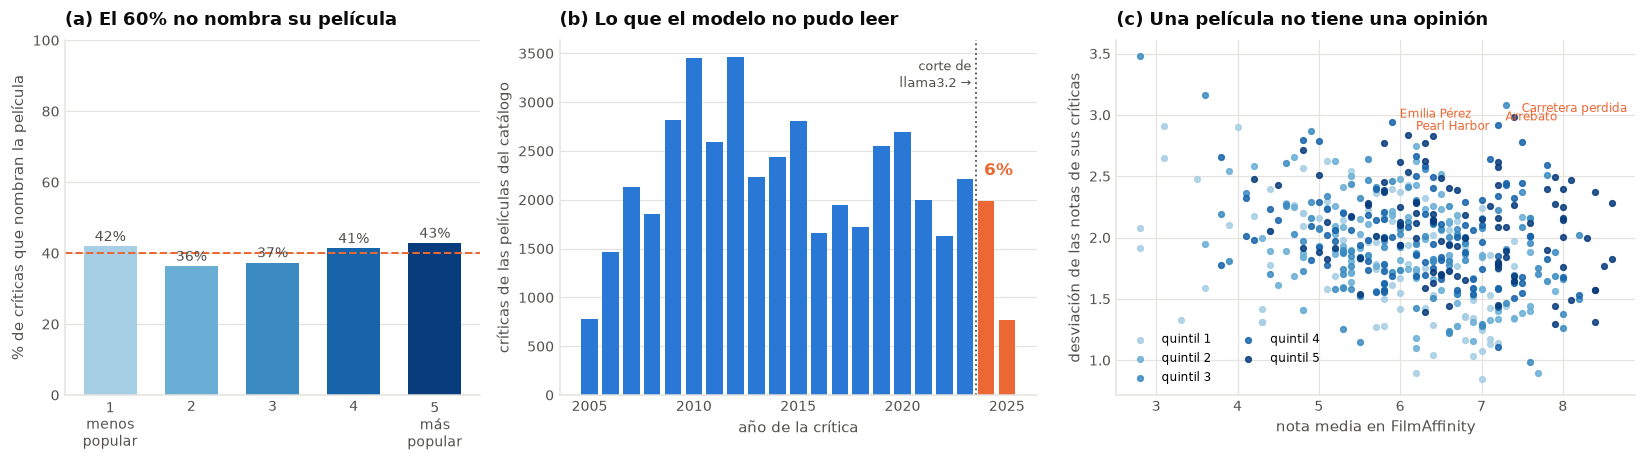

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15.2, 4.3), gridspec_kw={"width_ratios": [1, 1.15, 1.25]})

ax = axs[0]
m = resenas.groupby("quintil").menciona_titulo.mean() * 100
ax.bar(m.index, m.values, color=COLOR_QUINTIL, width=.65)
for q, v in m.items():
    ax.text(q, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, color=TINTA_2)
ax.axhline(resenas.menciona_titulo.mean() * 100, color=NARANJA, ls="--", lw=1.3)
ax.set_ylim(0, 100); ax.set_xticks(range(1, 6))
ax.set_xticklabels(["1\nmenos\npopular", "2", "3", "4", "5\nmás\npopular"])
ax.set_ylabel("% de críticas que nombran la película")
ax.set_title(f"(a) El {100 - resenas.menciona_titulo.mean() * 100:.0f}% no nombra su película")
ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)

ax = axs[1]
anios = sel.author_review_date_year.value_counts().sort_index()
ax.bar(anios.index, anios.values, color=[NARANJA if a >= 2024 else AZUL for a in anios.index], width=.8)
ax.axvline(2023.5, color=TINTA_2, ls=":", lw=1.2)
ax.text(2023.3, ax.get_ylim()[1] * .95, "corte de\nllama3.2 →", ha="right", va="top", fontsize=8.5, color=TINTA_2)
ax.text(2024.6, ax.get_ylim()[1] * .62, f"{tardias.mean():.0%}", ha="center", fontsize=11, color=NARANJA,
        fontweight="bold")
ax.set_xlabel("año de la crítica"); ax.set_ylabel("críticas de las películas del catálogo")
ax.set_title("(b) Lo que el modelo no pudo leer")
ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)

ax = axs[2]
for q in range(1, 6):
    g = catalogo[catalogo.quintil == q]
    ax.scatter(g.film_average_rating, g.dispersion, s=14, color=COLOR_QUINTIL[q - 1],
               label=f"quintil {q}", alpha=.85)
for _, r in DIVISIVAS.head(4).iterrows():
    ax.annotate(r.film_title, (r.film_average_rating, r.dispersion), fontsize=8, color=NARANJA,
                xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("nota media en FilmAffinity"); ax.set_ylabel("desviación de las notas de sus críticas")
ax.set_title("(c) Una película no tiene una opinión")
ax.legend(loc="lower left", fontsize=8, ncol=2); ax.grid(); ax.set_axisbelow(True); limpiar(ax)

plt.tight_layout(); guardar(fig, "02-lo-que-no-dicen"); plt.show()

**Lo que vimos.** Sólo el **40 %** de las críticas nombra la película de la que habla, y casi no depende
de la popularidad: va del 36 % al 43 % según el quintil. No es que las famosas se nombren más. Una
crítica se escribe *en la página* de su película y el título se da por sabido. Sin cabecera, tres de
cada cinco fragmentos no tienen cómo ser encontrados preguntando por el título (H1).

El 6 % de las críticas de estas películas es de 2024 o 2025, posterior al entrenamiento de `llama3.2`.
Es poco porque el catálogo tiene muchas películas antiguas, pero esas opiniones el modelo no las puede
conocer de ninguna manera. Y dentro de una misma película la nota varía casi 2 puntos (desviación
mediana de 1,94). En las más divisivas (*Carretera perdida*, *Emilia Pérez*, *Arrebato*, *Pearl
Harbor*) pasa de 2,8. Resumir "la opinión" con la crítica más parecida a la pregunta sería quedarse con
una de las dos mitades.

---

## 4. De críticas a fragmentos

### 4.1 Dos fallos que hereda el guía

Antes de trocear, dos comprobaciones sobre el código del guía, que reutilizamos como punto de partida.

**Las citas del guía no siempre son de donde dicen.** En la salida del chatbot del guía aparece la cita
*"¿Cómo tratar Las erupciones que producen los hongos? - …/dejar-de-desperdiciar-en-tu-vida"*: el título
no corresponde a la URL. No es un error del LLM, que no genera las citas, sino de `split_text`: arma un
diccionario indexado por URL y luego lo recorre con `zip` junto a la lista de títulos. Wikihow tiene
**varias filas por URL** (una por sección), así que el diccionario colapsa las repetidas y a partir de
ahí cada texto queda emparejado con el título de **otra** fila. La celda lo reproduce con tres filas.

**La memoria del guía nunca funcionó.** `ChatBot.follow_up_query` le pasa a `ollama.chat` un `str` donde
espera una lista de mensajes, y eso lanza una excepción. No se nota porque la interfaz llama a `bot(question)`
con `history=False`, el valor por defecto: el chatbot del guía responde cada pregunta sin recordar la
anterior.

In [12]:
# 1) split_text del guía, reducido a lo esencial, sobre un lote con una URL repetida
lote = {"title": ["¿Cómo A? (sección 1)", "¿Cómo A? (sección 2)", "¿Cómo B?"],
        "url": ["u/a", "u/a", "u/b"],
        "summary": ["resumen-a1", "resumen-a2", "resumen-b"],
        "document": ["texto-a1", "texto-a2", "texto-b"]}
articles = {url: s.split(" ") + d.split(" ") for url, s, d in zip(lote["url"], lote["summary"], lote["document"])}
print("título asignado          url    texto")
for title, (url, words) in zip(lote["title"], articles.items()):
    print(f"{title:<24} {url:<6} {words}")
print("→ el texto de 'u/b' queda con el título de A, y 'texto-a1' desaparece.\n")

# 2) follow_up_query del guía: un str en lugar de una lista de mensajes
try:
    ollama.chat(model=MODELO_LLM, messages="Historial: ... Siguiente pregunta: ... Pregunta general:")
except Exception as e:
    print(f"ollama.chat con un str → {type(e).__name__}: {e}")

título asignado          url    texto
¿Cómo A? (sección 1)     u/a    ['resumen-a2', 'texto-a2']
¿Cómo A? (sección 2)     u/b    ['resumen-b', 'texto-b']
→ el texto de 'u/b' queda con el título de A, y 'texto-a1' desaparece.

ollama.chat con un str → ValueError: dictionary update sequence element #0 has length 1; 2 is required


Aquí cada fragmento se construye **desde su fila**: lleva consigo `film_id`, `review_id` y nota, sin
diccionarios intermedios. Así una cita `[n]` siempre apunta a la crítica de la que salió el texto.

### 4.2 Tres troceados y una cabecera

El guía parte cada documento en ventanas de **100 palabras con solapamiento de 50**, siguiendo el
artículo original de RAG. Comparamos tres estrategias:

| Estrategia | Cómo | A favor | En contra |
|---|---|---|---|
| `palabras` | ventanas de 100 palabras, paso 50 (la del guía) | tamaño uniforme | corta frases; cada palabra se indexa dos veces |
| `oraciones` | oraciones completas hasta ~100 palabras, solapando una | no corta ideas | tamaños desiguales |
| `resena` | la crítica entera | todo el contexto | E5 trunca en 512 tokens (§3.3) |

Y, ortogonal a eso, la **cabecera contextual**: una línea que se antepone a cada fragmento de crítica
antes de calcular su *embedding*.

```
Joker (2019, Todd Phillips) · Crítica de usuario, nota 9/10 · «Título de la crítica»
<fragmento>
```

Es la misma idea que el *contextual retrieval* de Anthropic (2024), en versión barata: allí un LLM
escribe el contexto de cada fragmento; aquí lo tenemos gratis en los metadatos. La cabecera lleva la
**nota**, para que una pregunta por "las críticas negativas" tenga algo que encontrar. Las fichas no la
necesitan: ya empiezan por el título.

In [13]:
def trocear_palabras(texto, n=100, solape=50):
    # La estrategia del guía: ventanas de n palabras que avanzan de n - solape en n - solape.
    w = texto.split()
    if len(w) <= n:
        return [texto]
    paso = n - solape
    return [" ".join(w[i:i + n]) for i in range(0, len(w) - solape, paso)]

ORACION = re.compile(r"(?<=[.!?…])\s+")
def trocear_oraciones(texto, n=100):
    # Oraciones completas hasta ~n palabras; la última oración de un trozo abre el siguiente si cabe.
    oraciones = [o.strip() for o in ORACION.split(texto) if o.strip()]
    trozos, actual = [], []
    for o in oraciones:
        if actual and len(" ".join(actual + [o]).split()) > n:
            trozos.append(" ".join(actual))
            previa = actual[-1]
            actual = [previa] if len(f"{previa} {o}".split()) <= n else []
        actual.append(o)
    if actual:
        trozos.append(" ".join(actual))
    return trozos or [texto]

TROCEADORES = {"palabras": trocear_palabras, "oraciones": trocear_oraciones, "resena": lambda t: [t]}


def texto_ficha(p):
    original = (f" · título original: {p.film_original_title}"
                if p.film_original_title and p.film_original_title != p.film_title else "")
    return "\n".join([
        f"Película: {p.film_title} ({p.film_year}){original}",
        f"Dirección: {', '.join(p.film_director) or 'sin dato'} · País: {p.film_country} · Duración: {p.film_duration} min",
        f"Género: {', '.join(p.film_genre[:6]) or 'sin dato'}",
        f"Reparto: {', '.join(p.film_cast[:6]) or 'sin dato'}",
        f"Nota media en FilmAffinity: {p.film_average_rating:.1f}/10 ({p.film_number_of_ratings:,} votos)"
        f" · Críticas profesionales: {p.film_pro_reviews_positive} positivas, {p.film_pro_reviews_neutral} neutras,"
        f" {p.film_pro_reviews_negative} negativas",
        f"Dónde verla (suscripción): {', '.join(p.film_where_to_watch_sus[:5]) or 'sin dato'}",
        f"Sinopsis: {limpiar_texto(p.film_synospsis)}",
    ])

def cabecera(p, r, tipo):
    etiqueta = "Crítica de usuario" if tipo == "critica" else "Spoiler de una crítica de usuario"
    direccion = f", {p.film_director[0]}" if p.film_director else ""
    titulo = f" · «{r.titulo_critica}»" if r.titulo_critica else ""
    return f"{p.film_title} ({p.film_year}{direccion}) · {etiqueta}, nota {r.author_rating}/10{titulo}"

def construir_docs(estrategia):
    trocear = TROCEADORES[estrategia]
    filas = [dict(tipo="ficha", film_id=f, review_id=-1, nota=np.nan, titulo_critica="",
                  cabecera="", cuerpo=texto_ficha(p)) for f, p in P.iterrows()]
    for r in resenas.itertuples():
        p = P.loc[r.film_id]
        texto = f"{r.titulo_critica}. {r.cuerpo}" if r.titulo_critica else r.cuerpo
        partes = [("critica", t) for t in trocear(texto)]
        if r.spoiler:
            partes += [("spoiler", t) for t in trocear(r.spoiler)]
        for tipo, t in partes:
            filas.append(dict(tipo=tipo, film_id=r.film_id, review_id=r.review_id, nota=r.author_rating,
                              titulo_critica=r.titulo_critica, cabecera=cabecera(p, r, tipo), cuerpo=t))
    return pd.DataFrame(filas)

def textos_indice(docs, con_cabecera=True):
    if not con_cabecera:
        return docs.cuerpo.tolist()
    return [f"{c}\n{t}" if c else t for c, t in zip(docs.cabecera, docs.cuerpo)]

DOCS = {e: construir_docs(e) for e in TROCEADORES}
for e, d in DOCS.items():
    print(f"{e:<10} {len(d):>6,} documentos   " +
          "   ".join(f"{t}: {n:,}" for t, n in d.tipo.value_counts().items()))

ejemplo = DOCS["palabras"].query("tipo == 'critica'").iloc[1]
print("\nun fragmento tal como lo lee el encoder:\n")
print(textos_indice(pd.DataFrame([ejemplo]))[0][:600])

palabras   34,836 documentos   critica: 29,930   spoiler: 4,406   ficha: 500
oraciones  29,858 documentos   critica: 25,638   spoiler: 3,720   ficha: 500
resena      7,798 documentos   critica: 6,000   spoiler: 1,298   ficha: 500

un fragmento tal como lo lee el encoder:

¡Viven! (1993, Frank Marshall) · Crítica de usuario, nota 7/10 · «Sobreviven!»
Sobreviven!. Correcto filme de Frank Marshall. Consigue transmitir muy bien las sensaciones y angustias de la odisea de los protagonistas. El reparto, especialmente John Malkovich, optan por la credibilidad antes que un lucimiento que no tiene cabida aquí. El tema se trata con compasión y humanidad, sin perder el sentido de la aventura, porque las aventuras también son así de jodidas y de ingratas. La historia nos tiende la mano y nos invita a pasar, ver y sufrir. Podríamos haber sido nosotros... Dolorosa empatía co


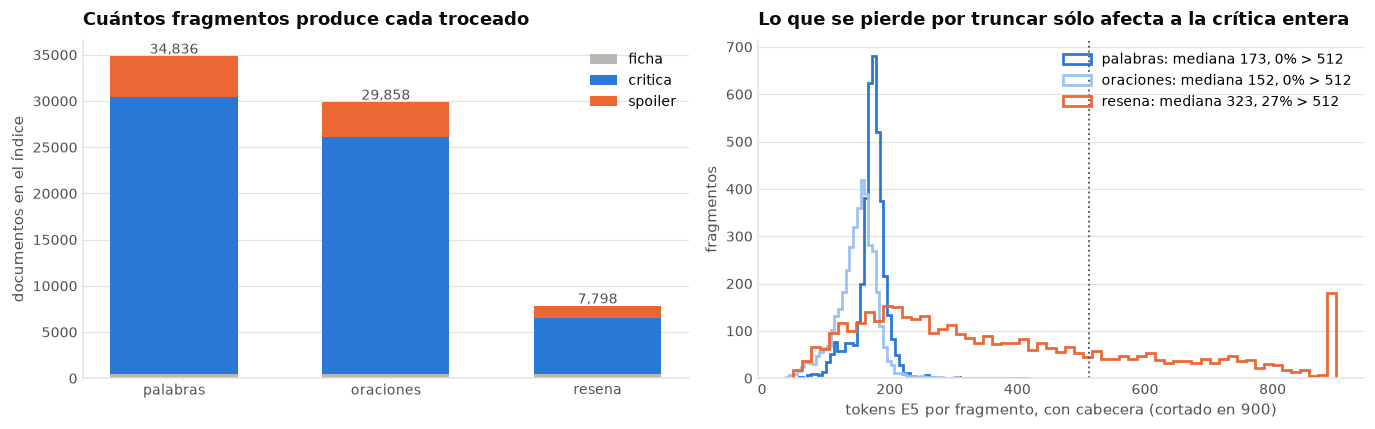

In [14]:
largos = {}
for e, d in DOCS.items():
    m = d.sample(min(4000, len(d)), random_state=SEED)
    largos[e] = np.array([len(x) for x in tok_e5(textos_indice(m), add_special_tokens=False)["input_ids"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.6, 4.0))
x = np.arange(len(DOCS))
for i, (e, d) in enumerate(DOCS.items()):
    abajo = 0
    for tipo, color in [("ficha", GRIS_REAL), ("critica", AZUL), ("spoiler", NARANJA)]:
        v = int((d.tipo == tipo).sum())
        ax1.bar(i, v, bottom=abajo, color=color, width=.6, label=tipo if i == 0 else None)
        abajo += v
    ax1.text(i, abajo + 300, f"{abajo:,}", ha="center", fontsize=9, color=TINTA_2)
ax1.set_xticks(x); ax1.set_xticklabels(DOCS.keys())
ax1.set_ylabel("documentos en el índice")
ax1.set_title("Cuántos fragmentos produce cada troceado")
ax1.legend(loc="upper right"); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

colores = {"palabras": AZUL, "oraciones": AZUL_CLARO, "resena": NARANJA}
for e, l in largos.items():
    ax2.hist(l.clip(max=900), bins=60, histtype="step", lw=1.8, color=colores[e],
             label=f"{e}: mediana {np.median(l):.0f}, {(l > 512).mean():.0%} > 512")
ax2.axvline(512, color=TINTA_2, ls=":", lw=1.2)
ax2.set_xlabel("tokens E5 por fragmento, con cabecera (cortado en 900)"); ax2.set_ylabel("fragmentos")
ax2.set_title("Lo que se pierde por truncar sólo afecta a la crítica entera")
ax2.legend(loc="upper right"); ax2.grid(axis="y"); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "03-troceado"); plt.show()

**Lo que vimos.** Con el troceado del guía, las 6.000 críticas y sus spoilers se convierten en 34.836
fragmentos, casi seis por crítica, porque cada palabra se indexa dos veces. Por oraciones salen 29.858 y
con la crítica entera, 7.798. Los fragmentos de las dos primeras estrategias caben siempre en E5
(medianas de 173 y 152 tokens con la cabecera). De la crítica entera, el 27 % pasa de 512 tokens y se
trunca. Cuál de las tres recupera mejor lo decide §6.4.

---

## 5. Un banco de preguntas que se corrige solo

El guía evalúa su RAG con una pregunta (*"¿Qué es el feng shui?"*) y mirando la respuesta. Para comparar
diez configuraciones hace falta algo que se pueda contar: **preguntas cuya respuesta correcta conocemos
de antemano**, construidas a partir del propio corpus, sin etiquetar nada a mano. Es la idea de los
bancos sintéticos de evaluación como RAGAS (Es *et al.*, 2023).

### 5.1 Tres familias

| Familia | Cómo se construye | Respuesta correcta | Métrica principal |
|---|---|---|---|
| **opinión** | plantilla con el título: *"¿Vale la pena ver {título}?"* (5 plantillas rotando) | cualquier documento de esa película | **P@5**: qué parte de los 5 primeros es de la película |
| **trama** | el LLM reescribe la sinopsis como la petición vaga de alguien que **no recuerda el título** | cualquier documento de esa película | **MRR@10**: 1 / posición del primer acierto |
| **aspecto** | el LLM lee un fragmento de una crítica y escribe la pregunta que ese fragmento responde | **esa crítica concreta** | **MRR@10** a nivel de crítica |

Las tres miden cosas distintas: *opinión* mide si el índice sabe de qué película habla cada fragmento,
*trama* si busca por significado, y *aspecto* si llega a la crítica precisa entre las doce de la misma
película. Hay 150 preguntas por familia, 30 por quintil de popularidad, la mitad sobre películas de
dev y la otra mitad sobre películas de test.

### 5.2 Generación y control de fugas

Una pregunta de *trama* que contenga el título no mide nada. Se comprueba cada una y se **descarta**
la que lo filtre. A una de *aspecto* que no lo nombre se le antepone (*"En «Joker», …"*), porque el
título es parte de la pregunta. Medimos también el solapamiento de palabras entre cada pregunta y su
texto de origen: si el LLM copiara frases, la búsqueda léxica tendría una ventaja injusta.

In [15]:
from sklearn.model_selection import train_test_split

STOP = set("""a al algo algun alguna algunas alguno algunos ante antes aquel aquella como con contra cual
cuando de del desde donde durante e el ella ellas ellos en entre era eran es esa esas ese eso esos esta
estas este esto estos fue fueron ha han hasta hay la las le les lo los mas me mi mis mucho muy nada ni
no nos o os otra otro para pero poco por porque que quien se sea ser si sido sin sobre su sus tambien
te tiene tienen todo todos tu tus un una uno unos unas y ya yo""".split())

def tokens(texto):
    # Palabras sin tildes ni mayúsculas y sin palabras vacías. También es el analizador de BM25 (§6.1).
    return [w for w in norm(texto).split() if w not in STOP and len(w) > 1]

def jaccard(a, b):
    a, b = set(tokens(a)), set(tokens(b))
    return len(a & b) / max(1, len(a | b))

def titulo_corto(t):
    return re.sub(r"\s*\(.*?\)\s*", " ", t).strip()

def limpiar_salida(s):
    # Primera línea útil de lo que devuelve el LLM, sin comillas ni rótulos del tipo "Pregunta:".
    lineas = [l.strip() for l in s.strip().splitlines() if l.strip()]
    lineas = [l for l in lineas if not l.endswith(":")] or lineas or [""]
    l = re.sub(r"^(pregunta( reescrita)?|petici[oó]n|respuesta)\s*:\s*", "", lineas[0], flags=re.I)
    return l.strip(' "“”«»\'*')

dev_ids, test_ids = train_test_split(catalogo.film_id, test_size=0.5, stratify=catalogo.quintil,
                                     random_state=SEED)
PARTICION = {**{f: "dev" for f in dev_ids}, **{f: "test" for f in test_ids}}
catalogo["particion"] = catalogo.film_id.map(PARTICION)

PLANTILLAS = ["¿Qué opinan los espectadores de {t}?", "¿Vale la pena ver {t}?",
              "¿Qué es lo que más gusta de {t}?", "¿Por qué critican {t}?", "¿Qué dicen las críticas de {t}?"]

PROMPT_TRAMA = """Eres un espectador que recuerda vagamente una película pero no su título. A partir de la sinopsis, escribe UNA petición breve (entre 10 y 25 palabras) para encontrarla, como la escribirías en un buscador o se la dirías a un amigo.
Reglas: no escribas el título ni nombres de personajes o actores; describe la situación con tus propias palabras, sin copiar frases de la sinopsis. Responde solo con la petición.

Sinopsis: {sinopsis}"""

PROMPT_ASPECTO = """Este es un fragmento de una crítica de usuario de la película «{t}»:

"{fragmento}"

Escribe UNA pregunta que haría un espectador y que este fragmento responde. La pregunta debe nombrar la película «{t}» y referirse al detalle CONCRETO que comenta el fragmento (un actor, un personaje, una escena, la música, la fotografía, el ritmo, el final…), de modo que sea este fragmento, y no cualquier crítica, el que la responde. No copies frases enteras del fragmento. Responde solo con la pregunta.

Ejemplo de fragmento: "...lo mejor es la banda sonora de Hans Zimmer, con ese órgano que retumba en las escenas espaciales..."
Ejemplo de pregunta: ¿Qué opinan de la música de Hans Zimmer en Interstellar?"""

def muestra(semilla):
    # la mitad de cada quintil en dev y la otra mitad en test
    return catalogo.groupby(["quintil", "particion"]).sample(N_PREG // 10, random_state=semilla)

In [16]:
RUTA_BANCO = RES / f"banco_preguntas{SUFIJO}.parquet"
rng = np.random.default_rng(SEED)

if RUTA_BANCO.exists():
    banco = pd.read_parquet(RUTA_BANCO)
    print(f"banco cargado de {RUTA_BANCO}")
else:
    filas, fugas, sin_titulo = [], 0, 0
    with medir("banco de preguntas (LLM)"):
        for i, p in enumerate(muestra(SEED).itertuples()):
            filas.append(dict(familia="opinion", film_id=p.film_id, review_id=-1, origen="",
                              pregunta=PLANTILLAS[i % len(PLANTILLAS)].format(t=titulo_corto(p.film_title))))

        for p in muestra(SEED + 1).itertuples():
            sinopsis = limpiar_texto(p.film_synospsis)
            q = limpiar_salida(llm.completion(PROMPT_TRAMA.format(sinopsis=sinopsis)))
            if any(f" {v} " in f" {norm(q)} " for v in VAR[p.film_id]) or len(q.split()) < 4:
                fugas += 1
                continue
            filas.append(dict(familia="trama", film_id=p.film_id, review_id=-1, origen=sinopsis, pregunta=q))

        for p in muestra(SEED + 2).itertuples():
            r = resenas[resenas.film_id == p.film_id].sample(1, random_state=int(rng.integers(1 << 30))).iloc[0]
            w = r.cuerpo.split()
            i0 = int(rng.integers(0, max(1, len(w) - 80)))
            fragmento = " ".join(w[i0:i0 + 80])
            t = titulo_corto(p.film_title)
            q = limpiar_salida(llm.completion(PROMPT_ASPECTO.format(t=t, fragmento=fragmento)))
            if not any(f" {v} " in f" {norm(q)} " for v in VAR[p.film_id]):
                sin_titulo += 1
                q = f"En «{t}», {q[:1].lower()}{q[1:]}"
            filas.append(dict(familia="aspecto", film_id=p.film_id, review_id=int(r.review_id),
                              origen=fragmento, pregunta=q))
    guardar_memo()
    banco = pd.DataFrame(filas)
    banco["id"] = np.arange(len(banco))
    banco["particion"] = banco.film_id.map(PARTICION)
    banco["quintil"] = banco.film_id.map(P.quintil)
    banco.to_parquet(RUTA_BANCO, index=False)
    print(f"trama: {fugas} preguntas descartadas por filtrar el título   "
          f"aspecto: {sin_titulo} sin título, completadas")

banco["solape"] = [jaccard(q, o) if o else np.nan for q, o in zip(banco.pregunta, banco.origen)]
print(banco.groupby(["familia", "particion"]).size().unstack().to_string())
print("\nsolapamiento de palabras con el texto de origen (Jaccard, mediana): " +
      "   ".join(f"{f} {g.solape.median():.2f}" for f, g in banco.groupby("familia") if g.solape.notna().any()))
print()
for f in ["opinion", "trama", "aspecto"]:
    for _, p in banco[banco.familia == f].head(3).iterrows():
        print(f"[{f:<8}] {P.loc[p.film_id].film_title[:26]:<26} → {p.pregunta}")

banco cargado de resultados\banco_preguntas.parquet
particion  dev  test
familia             
aspecto     75    75
opinion     75    75
trama       74    74

solapamiento de palabras con el texto de origen (Jaccard, mediana): aspecto 0.05   trama 0.12

[opinion ] La puerta abierta          → ¿Qué opinan los espectadores de La puerta abierta?
[opinion ] Kill Boy                   → ¿Vale la pena ver Kill Boy?
[opinion ] Les combattants            → ¿Qué es lo que más gusta de Les combattants?
[trama   ] Amor y amistad             → Busco película de comedia romántica de finales del siglo XVIII, con una joven viuda que busca un marido para sí y su hija, en una sociedad aristocrática.
[trama   ] Gloria Bell                → Busco una película de comedia romántica de los 90s sobre una mujer que vive dos vidas: oficina y fiesta, con un remake de un clásico
[trama   ] El elemento del crimen     → Busco una película de misterio donde un inspector de policía regresa a El Cairo para reconstruir

**Lo que vimos.** El banco queda con 448 preguntas: 75 de opinión y 75 de aspecto en cada partición, y
74 de trama, porque dos peticiones filtraban el título y se descartaron. Otras dos de aspecto no lo
nombraban y se completaron. El solapamiento de palabras con el texto de origen es bajo (Jaccard mediano
de 0,12 en trama y 0,05 en aspecto): el LLM parafrasea, no copia.

Las de trama suenan a lo que pretenden (*"Busco una película de misterio donde un inspector de policía
regresa a El Cairo para reconstruir un crimen a través de la hipnosis…"*). Las de aspecto a veces son
genéricas (*"¿Qué opinan de la interpretación de los actores en…?"*), y eso hace más difícil esa
familia: entre doce críticas de la misma película varias pueden hablar de los actores, y sólo una cuenta
como acierto. Por eso sus cifras absolutas son más bajas y las leemos en relativo, peldaño contra
peldaño.

---

## 6. Recuperación

### 6.1 Las piezas

**E5 y sus prefijos.** E5 (Wang *et al.*, 2022) se entrenó con pares en los que la pregunta empieza por
`query: ` y el pasaje por `passage: `, y su ficha avisa de que sin ellos el rendimiento cae. El guía no
los pone. Los ponemos y medimos la diferencia (H2).

**BM25.** La búsqueda léxica clásica (Robertson y Zaragoza, 2009): puntúa por palabras compartidas,
dando más peso a las raras. Para nombres propios y títulos suele ganarle a un encoder denso, que
comprime *"Oppenheimer"* en el mismo vector que todo lo demás. La implementamos sobre una matriz
dispersa, con lo que cada consulta es un único producto.

**Fusión RRF.** La híbrida combina las dos listas por **posición**, no por puntuación (Cormack *et al.*,
2009): cada documento suma 1/(60 + posición) en cada lista. Así no hay que calibrar escalas que no se
parecen.

**Reranker.** Un *cross-encoder* (`bge-reranker-v2-m3`, multilingüe) lee la pregunta y el fragmento
**juntos**, con atención cruzada entre ambos, y devuelve una relevancia entre 0 y 1. Es demasiado caro
para recorrer el índice entero, pero barato para reordenar los 20 primeros. Además, su puntuación es
absoluta, y eso permite la compuerta de abstención de §8.3.

**MMR.** *Maximal Marginal Relevance* (Carbonell y Goldstein, 1998): cada fuente nueva se elige
equilibrando su relevancia con su parecido a las ya elegidas, con un peso λ. Con λ = 1 es el orden del
reranker; al bajar λ se gana variedad.

**Una fuente por crítica.** Con fragmentos solapados, los cinco mejores pueden ser trozos de la misma
crítica. Tras el reranker se queda sólo el mejor fragmento de cada crítica. Es la versión mínima de
agrupar los fragmentos por documento padre.

**Router.** Reglas, no un modelo: busca en la pregunta el título de alguna película del catálogo (un
título de una sola palabra tiene que ir con mayúscula, para no confundir *Amor* con *amor*), detecta si
se piden críticas negativas o positivas y si se aceptan *spoilers*. Lo que detecta se aplica como filtro.

In [17]:
from sentence_transformers import SentenceTransformer, CrossEncoder

_encoders = {}
def encoder(nombre):
    if nombre not in _encoders:
        m = SentenceTransformer(ENCODERS[nombre], device=DEVICE)
        if DEVICE == "cuda":
            m.half()
        _encoders[nombre] = m
    return _encoders[nombre]

RUTA_TIEMPOS = CACHE / f"tiempos_embeddings{SUFIJO}.json"
TIEMPOS_EMB = json.loads(RUTA_TIEMPOS.read_text()) if RUTA_TIEMPOS.exists() else {}

def embeber(docs, estrategia, nombre=ENCODER, con_cabecera=True, prefijo=True):
    clave = (f"{nombre}-{estrategia}-{'cab' if con_cabecera else 'sincab'}-"
             f"{'pref' if prefijo else 'sinpref'}-{len(docs)}{SUFIJO}")
    ruta = CACHE / f"emb-{clave}.npy"
    if ruta.exists():
        return np.load(ruta)
    textos = textos_indice(docs, con_cabecera)
    if prefijo:
        textos = ["passage: " + t for t in textos]
    modelo = encoder(nombre)                 # la descarga, la carga y el calentamiento no cuentan
    modelo.encode(textos[:64], batch_size=64, show_progress_bar=False)
    with medir(f"embeddings {clave}") as m:
        E = modelo.encode(textos, batch_size=64, normalize_embeddings=True,
                                   convert_to_numpy=True, show_progress_bar=False).astype(np.float32)
    TIEMPOS_EMB[clave] = m.seg
    RUTA_TIEMPOS.write_text(json.dumps(TIEMPOS_EMB))
    np.save(ruta, E)
    return E

def embeber_consultas(consultas, nombre=ENCODER, prefijo=True):
    consultas = list(consultas)
    if prefijo:
        consultas = ["query: " + q for q in consultas]
    return encoder(nombre).encode(consultas, batch_size=64, normalize_embeddings=True,
                                  convert_to_numpy=True, show_progress_bar=False).astype(np.float32)


from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer

class BM25:
    # Okapi BM25 sobre una matriz dispersa documentos × términos: puntuar es sumar columnas.
    def __init__(self, textos, k1=1.5, b=0.75):
        self.cv = CountVectorizer(analyzer=tokens)
        tf = self.cv.fit_transform(textos).tocoo()
        n_docs = tf.shape[0]
        df = np.bincount(tf.col, minlength=tf.shape[1])
        idf = np.log(1 + (n_docs - df + 0.5) / (df + 0.5))
        largo = np.bincount(tf.row, weights=tf.data, minlength=n_docs)
        norma = k1 * (1 - b + b * largo / largo.mean())
        w = tf.data * (k1 + 1) / (tf.data + norma[tf.row]) * idf[tf.col]
        self.W = sparse.csc_matrix((w.astype(np.float32), (tf.row, tf.col)), shape=tf.shape)

    def puntuar(self, consulta):
        cols = np.unique(self.cv.transform([consulta]).indices)
        return np.asarray(self.W[:, cols].sum(axis=1)).ravel()


_rr = {}
def reranker():
    if "modelo" not in _rr:
        m = CrossEncoder(RERANKER, device=DEVICE, max_length=512)
        if DEVICE == "cuda":
            m.model.half()
        _rr["modelo"] = m
    return _rr["modelo"]

def relevancia(consulta, textos):
    # Puntuación del cross-encoder, con memoria: la misma pareja no se puntúa dos veces.
    claves = [hashlib.sha1(f"{consulta}\x00{t}".encode()).hexdigest()[:20] for t in textos]
    faltan = {c: t for c, t in zip(claves, textos) if c not in _memo_rr}
    if faltan:
        s = reranker().predict([(consulta, t) for t in faltan.values()], batch_size=32,
                               show_progress_bar=False)
        _memo_rr.update({c: float(v) for c, v in zip(faltan, s)})
    return np.array([_memo_rr[c] for c in claves])

def mmr_orden(rel, V, lam, k):
    # Maximal Marginal Relevance: relevancia normalizada contra el parecido con lo ya elegido.
    rel = (rel - rel.min()) / (rel.max() - rel.min() + 1e-9)
    sim = V @ V.T
    elegidos = [int(np.argmax(rel))]
    while len(elegidos) < min(k, len(rel)):
        resto = [i for i in range(len(rel)) if i not in elegidos]
        valor = [lam * rel[i] - (1 - lam) * sim[i, elegidos].max() for i in resto]
        elegidos.append(resto[int(np.argmax(valor))])
    return elegidos

In [18]:
# Router: título, nota y spoilers, por reglas.
def variantes_caso(p):
    out = []
    for t in (re.sub(r"\(.*?\)", "", p.film_title), p.film_original_title or ""):
        if len(norm(t)) >= 4:
            out.append((norm(t), norm_caso(t)))
    return out

VARIANTES = {}
for f, p in P.iterrows():
    for v, vc in variantes_caso(p):
        VARIANTES.setdefault(v, (f, vc))
ORDEN_VAR = sorted(VARIANTES, key=len, reverse=True)       # el título más largo gana: "Joker: Folie à Deux" antes que "Joker"

def detectar_pelicula(pregunta):
    q, qc = f" {norm(pregunta)} ", f" {norm_caso(pregunta)} "
    for v in ORDEN_VAR:
        f, vc = VARIANTES[v]
        if (" " in v and f" {v} " in q) or (" " not in v and f" {vc} " in qc):
            return f
    return None

NEG, MED, POS = (1, 2, 3, 4), (5, 6), (7, 8, 9, 10)
PIDE_NEG = re.compile(r"\b(malas? notas?|notas? bajas?|negativ\w*|no (le|les) gusto|odiaron|detestaron|"
                      r"decepcion\w*|peores criticas|la pusieron mal)\b")
PIDE_POS = re.compile(r"\b(buenas? notas?|notas? altas?|positiv\w*|(le|les) encanto|elogi\w*|mejores criticas)\b")
PIDE_SPOILER = re.compile(r"\b(spoilers?|como termina|el final|desenlace)\b")

def analizar(pregunta):
    q = norm(pregunta)
    f = detectar_pelicula(pregunta)
    return {"film_ids": [f] if f else None,
            "notas": NEG if PIDE_NEG.search(q) else POS if PIDE_POS.search(q) else None,
            "spoilers": bool(PIDE_SPOILER.search(q))}

for q in ["¿Qué le critican a Joker los que le pusieron mala nota?",
          "Busco una historia de amor en la Segunda Guerra Mundial",
          "¿Cómo termina Interstellar? No me importan los spoilers"]:
    a = analizar(q)
    peli = P.loc[a["film_ids"][0]].film_title if a["film_ids"] else None
    print(f"{q}\n   → película: {peli}   notas: {a['notas']}   spoilers: {a['spoilers']}")

¿Qué le critican a Joker los que le pusieron mala nota?
   → película: Joker   notas: (1, 2, 3, 4)   spoilers: False
Busco una historia de amor en la Segunda Guerra Mundial
   → película: None   notas: None   spoilers: False
¿Cómo termina Interstellar? No me importan los spoilers
   → película: Interstellar   notas: None   spoilers: True


In [19]:
class Recuperador:
    # Búsqueda densa, léxica o híbrida sobre un conjunto de documentos, con filtros, reranker y MMR.

    def __init__(self, docs, E, nombre=ENCODER, prefijo=True, con_cabecera=True, bm25=None):
        self.docs = docs.reset_index(drop=True)
        self.E, self.nombre, self.prefijo, self.con_cabecera = E, nombre, prefijo, con_cabecera
        self.textos = textos_indice(self.docs, con_cabecera)
        self._bm25 = bm25
        self.film, self.tipo, self.nota = self.docs.film_id.values, self.docs.tipo.values, self.docs.nota.values

    @property
    def bm25(self):
        if self._bm25 is None:
            self._bm25 = BM25(self.textos)
        return self._bm25

    def mascara(self, film_ids=None, notas=None, spoilers=True):
        if film_ids is None and notas is None and spoilers:
            return None
        m = np.ones(len(self.docs), bool)
        if film_ids is not None:
            m &= np.isin(self.film, list(film_ids))
        if notas is not None:
            m &= (self.tipo == "ficha") | np.isin(self.nota, list(notas))
        if not spoilers:
            m &= self.tipo != "spoiler"
        return m

    @staticmethod
    def _top(s, n, mascara):
        if mascara is not None:
            s = np.where(mascara, s, -np.inf)
            n = min(n, int(mascara.sum()))
        n = min(n, len(s))
        if n <= 0:
            return np.array([], dtype=int)
        i = np.argpartition(-s, n - 1)[:n]
        return i[np.argsort(-s[i], kind="stable")]

    def candidatos(self, consulta, q, modo, mascara, n):
        if modo == "hibrido":
            rrf = defaultdict(float)
            for lista in (self._top(self.E @ q, 100, mascara),
                          self._top(self.bm25.puntuar(consulta), 100, mascara)):
                for rango, j in enumerate(lista, 1):
                    rrf[j] += 1 / (60 + rango)
            orden = sorted(rrf, key=rrf.get, reverse=True)[:n]
            return np.array(orden, dtype=int), np.array([rrf[j] for j in orden])
        s = self.E @ q if modo == "denso" else self.bm25.puntuar(consulta)
        i = self._top(s, n, mascara)
        return i, s[i]

    def buscar(self, consulta, k=5, modo="hibrido", rerank=True, mmr=None, q=None, por_critica=False,
               film_ids=None, notas=None, spoilers=True, n_cand=N_CAND):
        mascara = self.mascara(film_ids, notas, spoilers)
        if q is None and modo != "bm25":
            q = embeber_consultas([consulta], self.nombre, self.prefijo)[0]
        n = max(n_cand, k) if (rerank or mmr or por_critica) else k
        idx, s = self.candidatos(consulta, q, modo, mascara, n)
        res = self.docs.iloc[idx].copy()
        res["score"] = s
        if rerank and len(res):
            res["relevancia"] = relevancia(consulta, [self.textos[j] for j in idx])
            res = res.sort_values("relevancia", ascending=False, kind="stable")
        if por_critica:
            # una fuente por crítica: de cada crítica (o spoiler, o ficha) sólo su mejor fragmento
            res = res.drop_duplicates(["film_id", "review_id", "tipo"])
        if mmr is not None and len(res) > k:
            rel = res["relevancia"].values if "relevancia" in res else res["score"].values
            res = res.iloc[mmr_orden(rel, self.E[res.index.values], mmr, k)]
        return res.head(k)


_recs = {}
def rec_para(estrategia="palabras", con_cabecera=True, prefijo=True, nombre=ENCODER):
    # Un recuperador por configuración de índice; el BM25 se comparte entre los que indexan el mismo texto.
    clave = (estrategia, con_cabecera, prefijo, nombre)
    if clave not in _recs:
        E = embeber(DOCS[estrategia], estrategia, nombre, con_cabecera, prefijo)
        bm = next((r._bm25 for (e, c, _, _), r in _recs.items()
                   if e == estrategia and c == con_cabecera and r._bm25 is not None), None)
        _recs[clave] = Recuperador(DOCS[estrategia], E, nombre, prefijo, con_cabecera, bm25=bm)
    return _recs[clave]

### 6.2 Las métricas

`evaluar()` pasa un banco de preguntas por un recuperador y anota, pregunta a pregunta, las métricas de
§5.1 sobre los 10 primeros resultados. `dif_pareada()` compara dos configuraciones **sobre las mismas
preguntas**: remuestrea preguntas y mide la desviación de la diferencia media. Una diferencia cuenta
cuando supera dos de esas desviaciones. Es más exigente que comparar intervalos por separado, y más
justo, porque una pregunta difícil lo es para las dos configuraciones.

In [20]:
PRINCIPAL = {"opinion": ("p5_pelicula", "P@5 película"),
             "trama":   ("mrr_pelicula", "MRR@10 película"),
             "aspecto": ("mrr_critica", "MRR@10 crítica")}
FAMILIAS = list(PRINCIPAL)

def evaluar(rec, banco, nombre, router=False, k=10, **kw):
    modo = kw.get("modo", "hibrido")
    Q = (embeber_consultas(banco.pregunta, rec.nombre, rec.prefijo) if modo != "bm25"
         else [None] * len(banco))
    filas = []
    for p, q in zip(banco.itertuples(), Q):
        film_ids = analizar(p.pregunta)["film_ids"] if router else None
        res = rec.buscar(p.pregunta, k=k, q=q, film_ids=film_ids, **kw)
        rel = res.film_id.values == p.film_id
        rel_c = (res.review_id.values == p.review_id) & (p.familia == "aspecto")
        pos, pos_c = np.flatnonzero(rel), np.flatnonzero(rel_c)
        filas.append({
            "config": nombre, "id": p.id, "familia": p.familia, "particion": p.particion, "quintil": p.quintil,
            "p5_pelicula": float(rel[:5].mean()) if len(rel) else 0.0,
            "hit5_pelicula": float(rel[:5].any()),
            "mrr_pelicula": 1 / (pos[0] + 1) if len(pos) else 0.0,
            "mrr_critica": (1 / (pos_c[0] + 1) if len(pos_c) else 0.0) if p.familia == "aspecto" else np.nan,
            "hit5_critica": float(rel_c[:5].any()) if p.familia == "aspecto" else np.nan,
        })
    return pd.DataFrame(filas)

def media_sd(x, B=N_BOOT, semilla=SEED):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    r = np.random.default_rng(semilla)
    return x.mean(), x[r.integers(0, len(x), (B, len(x)))].mean(axis=1).std()

def resumir(ev):
    filas = []
    for (cfg, fam), g in ev.groupby(["config", "familia"], sort=False):
        m, sd = media_sd(g[PRINCIPAL[fam][0]])
        filas.append({"config": cfg, "familia": fam, "media": m, "sd": sd})
    return pd.DataFrame(filas)

def dif_pareada(ev, a, b, familia, B=N_BOOT, semilla=SEED):
    col = PRINCIPAL[familia][0]
    xa = ev[(ev.config == a) & (ev.familia == familia)].set_index("id")[col]
    xb = ev[(ev.config == b) & (ev.familia == familia)].set_index("id")[col]
    x = (xa - xb).dropna().values
    r = np.random.default_rng(semilla)
    return x.mean(), x[r.integers(0, len(x), (B, len(x)))].mean(axis=1).std()

def tabla(ev):
    s = resumir(ev)
    s["valor"] = [f"{m:.3f} ± {sd:.3f}" for m, sd in zip(s.media, s.sd)]
    t = s.pivot(index="config", columns="familia", values="valor").reindex(
        index=list(dict.fromkeys(ev.config)), columns=FAMILIAS)
    t.columns = [f"{f} · {PRINCIPAL[f][1]}" for f in FAMILIAS]
    return t

def media_familias(ev, cfg):
    s = resumir(ev[ev.config == cfg])
    return s.media.mean()

dev, test = banco[banco.particion == "dev"], banco[banco.particion == "test"]
print(f"dev: {len(dev)} preguntas   test: {len(test)} preguntas")

dev: 224 preguntas   test: 224 preguntas


### 6.3 Un ejemplo antes de los números

La pregunta de opinión de test en la que **peor** le va a la réplica del guía, contestada por dos
índices densos con el mismo encoder: la réplica (fragmentos sin cabecera, sin prefijos) y el mismo índice
con cabecera y prefijos. Es un caso extremo elegido a propósito, para ver el mecanismo. La media está en
la escalera de §6.6, y elegir un ejemplo no toma ninguna decisión. Calcular los *embeddings* de los
índices de esta sección es lo más caro del notebook; quedan guardados en `cache/`.

In [21]:
def mostrar(res, n=5):
    for i, d in enumerate(res.head(n).itertuples(), 1):
        p = P.loc[d.film_id]
        nota = f"{int(d.nota):>2}/10" if d.tipo != "ficha" else "     "
        print(f"  {i}. {d.tipo:<8}{nota}  {p.film_title[:26]:<26}  {d.cuerpo[:70]!r}")

op_test = test[test.familia == "opinion"]
ev0 = evaluar(rec_para("palabras", False, False), op_test, "L0", modo="denso", rerank=False, k=5)
peor = ev0.sort_values(["p5_pelicula", "id"]).iloc[0]
ej = banco.set_index("id").loc[peor.id]
PREGUNTA_EJEMPLO = ej.pregunta
print(f"P@5 de la réplica del guía en las {len(op_test)} preguntas de opinión de test: "
      f"media {ev0.p5_pelicula.mean():.2f}, mínimo {peor.p5_pelicula:.2f}")
print(f"«{PREGUNTA_EJEMPLO}»: {resenas[resenas.film_id == ej.film_id].menciona_titulo.mean():.0%} de las "
      f"críticas de esa película la nombran\n")
for nombre, rec in [("réplica del guía (sin cabecera, sin prefijos)", rec_para("palabras", False, False)),
                    ("con cabecera y prefijos", rec_para("palabras", True, True))]:
    print(f"{nombre}:")
    mostrar(rec.buscar(PREGUNTA_EJEMPLO, k=5, modo="denso", rerank=False))
    print()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

P@5 de la réplica del guía en las 75 preguntas de opinión de test: media 0.81, mínimo 0.00
«¿Qué opinan los espectadores de Recuerda?»: 25% de las críticas de esa película la nombran



réplica del guía (sin cabecera, sin prefijos):
  1. critica  3/10  Reeker                      'transpasando la pantalla. Rematamos con un final en el que nos tratan '
  2. critica  7/10  The Duke of Burgundy        'La química es innegable y hasta el físico les acompaña, aportando un c'
  3. critica  6/10  Friends: The Reunion        'si viste la serie, donde sus mejores momentos son los detrás de cámara'
  4. critica  4/10  Una historia de Brooklyn    'minutos cuenta la historia perfectamente). Por eso le doy un cuatro, p'
  5. critica  3/10  Mejor otro día              'para mucho. Especialmente recomendada para quienes les guste el género'

con cabecera y prefijos:
  1. critica  6/10  Recuerda                    'La mente se defiende de los malos recuerdos. Son esos detalles que se '
  2. critica  3/10  Recuerda                    'lógica que el crimen necesita. Pues no, ten por seguro que el culpable'
  3. critica  6/10  Recuerda                    'buenos los pasos con los que la

**Lo que vimos.** La réplica del guía acierta de media 0,81 en P@5. Con *Recuerda* (Hitchcock, 1945),
cuyas críticas la nombran sólo en un 25 %, no trae **ninguna** fuente de la película: devuelve críticas
de *Reeker*, *The Duke of Burgundy* o *Friends: The Reunion* que hablan de finales, de química entre
actores, de "la historia". Son textos que se parecen a *una opinión*, no a *esta película*. Con la
cabecera, las cinco fuentes son de *Recuerda*. Es el mecanismo de H1 en un solo caso.

### 6.4 Decisiones en dev: troceado y encoder

Dos decisiones con reglas escritas antes de mirar:

- **Troceado**: el de mayor media de las tres métricas principales con la búsqueda completa (híbrida +
  reranker). Se muestra también con búsqueda densa sola, para ver si la decisión depende de ella.
- **Encoder**: el más pequeño de los tres E5 que quede a menos de 0,01 del mejor en búsqueda densa sobre
  `palabras` con cabecera. El coste de calcular los *embeddings* va al eje horizontal de la figura.

In [22]:
evs = []
with medir("evaluación: troceado (dev)"):
    for e in TROCEADORES:
        rec = rec_para(e)
        evs.append(evaluar(rec, dev, f"{e} · denso", modo="denso", rerank=False))
        evs.append(evaluar(rec, dev, f"{e} · híbrido + reranker", modo="hibrido", rerank=True))
ev_trozo = pd.concat(evs)
guardar_memo()
TROCEADO = max(TROCEADORES, key=lambda e: media_familias(ev_trozo, f"{e} · híbrido + reranker"))

evs = []
with medir("evaluación: encoder (dev)"):
    for nombre in ENCODERS:
        evs.append(evaluar(rec_para("palabras", nombre=nombre), dev, nombre, modo="denso", rerank=False))
ev_enc = pd.concat(evs)
medias_enc = {n: media_familias(ev_enc, n) for n in ENCODERS}
mejor = max(medias_enc.values())
ENCODER_FINAL = next(n for n in ENCODERS if medias_enc[n] >= mejor - 0.01)

print(tabla(ev_trozo).to_string())
print()
print(tabla(ev_enc).to_string())
n_frag = len(DOCS["palabras"])
seg_enc = {n: TIEMPOS_EMB.get(f"{n}-palabras-cab-pref-{n_frag}{SUFIJO}", np.nan) for n in ENCODERS}
print("\nsegundos de embeddings por cada 1.000 fragmentos: " +
      "   ".join(f"{n} {1000 * s / n_frag:.1f}" for n, s in seg_enc.items()))
print(f"\n→ troceado elegido: {TROCEADO}    encoder elegido: {ENCODER_FINAL}")
for n in [n for n in _encoders if n not in (ENCODER, ENCODER_FINAL)]:
    del _encoders[n]          # libera la GPU para el LLM
torch.cuda.empty_cache()
pd.concat([ev_trozo, ev_enc]).to_csv(RES / f"recuperacion_dev{SUFIJO}.csv", index=False)

   ⏱  evaluación: troceado (dev): 0.3 min   (acumulado 0.3 min)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   ⏱  evaluación: encoder (dev): 0.3 min   (acumulado 0.6 min)
                               opinion · P@5 película trama · MRR@10 película aspecto · MRR@10 crítica
config                                                                                                
palabras · denso                        0.987 ± 0.013           0.615 ± 0.050            0.440 ± 0.050
palabras · híbrido + reranker           0.987 ± 0.013           0.954 ± 0.022            0.622 ± 0.046
oraciones · denso                       0.984 ± 0.013           0.631 ± 0.049            0.429 ± 0.047
oraciones · híbrido + reranker          0.987 ± 0.013           0.953 ± 0.023            0.637 ± 0.046
resena · denso                          0.984 ± 0.013           0.647 ± 0.050            0.390 ± 0.040
resena · híbrido + reranker             0.987 ± 0.013           0.961 ± 0.020            0.595 ± 0.045

       opinion · P@5 película trama · MRR@10 película aspecto · MRR@10 crítica
config                           

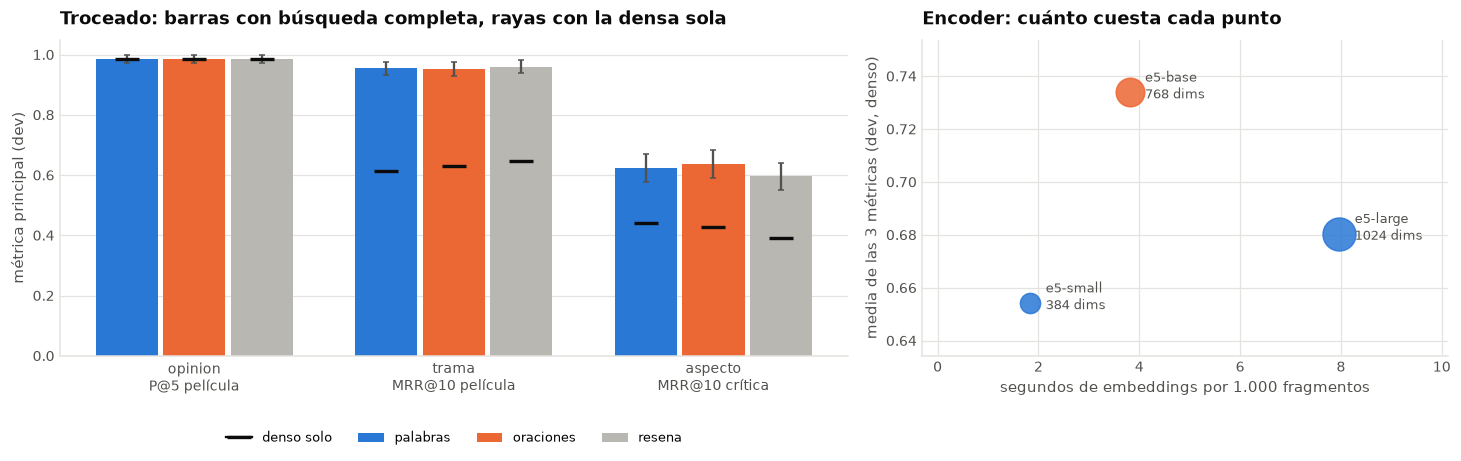

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})

s = resumir(ev_trozo)
ancho = .26
for j, e in enumerate(TROCEADORES):
    for i, f in enumerate(FAMILIAS):
        h = s[(s.config == f"{e} · híbrido + reranker") & (s.familia == f)].iloc[0]
        d = s[(s.config == f"{e} · denso") & (s.familia == f)].iloc[0]
        x = i + (j - 1) * ancho
        color = NARANJA if e == TROCEADO else [AZUL, AZUL_CLARO, GRIS_REAL][j]
        ax1.bar(x, h.media, width=ancho * .92, color=color, yerr=h.sd, ecolor=TINTA_2, capsize=2,
                label=e if i == 0 else None)
        ax1.plot(x, d.media, marker="_", ms=16, mew=2.2, color=TINTA, label="denso solo" if (i == 0 and j == 0) else None)
ax1.set_xticks(range(len(FAMILIAS)))
ax1.set_xticklabels([f"{f}\n{PRINCIPAL[f][1]}" for f in FAMILIAS])
ax1.set_ylim(0, 1.05); ax1.set_ylabel("métrica principal (dev)")
ax1.set_title("Troceado: barras con búsqueda completa, rayas con la densa sola")
ax1.legend(loc="upper center", bbox_to_anchor=(.5, -.2), ncol=4, fontsize=8.5)
ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

dims = {n: rec_para("palabras", nombre=n).E.shape[1] for n in ENCODERS}
for n in ENCODERS:
    x = 1000 * seg_enc[n] / n_frag
    ax2.scatter(x, medias_enc[n], s=dims[n] / 2.2, color=NARANJA if n == ENCODER_FINAL else AZUL, alpha=.85)
    ax2.annotate(f"e5-{n}\n{dims[n]} dims", (x, medias_enc[n]), xytext=(10, -4), textcoords="offset points",
                 fontsize=8.5, color=TINTA_2)
ax2.set_xlabel("segundos de embeddings por 1.000 fragmentos")
ax2.set_ylabel("media de las 3 métricas (dev, denso)")
ax2.set_title("Encoder: cuánto cuesta cada punto")
ax2.margins(x=.35, y=.25); ax2.grid(); ax2.set_axisbelow(True); limpiar(ax2)

plt.tight_layout(); guardar(fig, "04-troceado-y-encoder"); plt.show()

**Lo que vimos.** **El troceado apenas importa** una vez que la búsqueda es completa: 0,855 con
palabras, 0,859 con oraciones y 0,848 con la crítica entera, diferencias mucho menores que el ruido de
cada métrica (±0,02 a ±0,05). La regla elige oraciones por cuatro milésimas, y es una elección sin
consecuencias. Con la búsqueda densa sola sí hay un matiz: la crítica entera es la mejor en trama (0,65)
y la peor en aspecto (0,39). El *embedding* de una crítica larga resume de qué va la película, pero
diluye el detalle.

**El encoder sí importa, y no en el sentido esperado.** `e5-base` (0,734 de media) supera a
`e5-large`, el del guía (0,680), en trama (0,69 frente a 0,62) y en aspecto (0,52 frente a 0,44), y
calcula los *embeddings* en la mitad de tiempo (3,8 s frente a 8,0 s por cada mil fragmentos).
`e5-small` es el más barato y el peor. No tenemos una explicación cerrada y no lo generalizaríamos sin
repetirlo con otro banco. Con estas preguntas coloquiales y la cabecera repetida en cada fragmento, el
modelo grande no compró calidad. Por la regla, el sistema final usa `e5-base`.

### 6.5 Diversidad: ¿cinco fuentes o cinco veces la misma?

Con el troceado del guía, una crítica larga produce cuatro o cinco fragmentos solapados. Si la pregunta
es *"¿qué opinan de Joker?"*, el reranker puede llenar las cinco plazas con trozos de **la misma**
crítica, y el LLM resumiría una opinión creyendo que son cinco. La prueba de humo lo mostró: la respuesta
citaba [2] y [5], y eran dos trozos de la misma crítica.

Comparamos tres cosas sobre las preguntas de opinión de dev, con el router activo: el orden del reranker
tal cual, **una fuente por crítica**, y una fuente por crítica más **MMR** con varios λ. Medimos cuántas
críticas distintas y cuántas bandas de nota (las cinco de las Sesiones 3–4) entran en las cinco primeras
fuentes, y cuánto baja la relevancia media a cambio. MMR lo tiene difícil con la cabecera: todos los
fragmentos de una película empiezan igual y se parecen entre sí, así que "parecido" deja de distinguir
críticas.

In [24]:
rec_final = rec_para(TROCEADO, nombre=ENCODER_FINAL)
op_dev = dev[dev.familia == "opinion"]
Q = embeber_consultas(op_dev.pregunta, rec_final.nombre)
DIVERSIDAD = {"reranker": dict(), "1 por crítica": dict(por_critica=True)}
DIVERSIDAD.update({f"+ MMR {l}": dict(por_critica=True, mmr=l) for l in (0.85, 0.7, 0.55, 0.4)})
filas = []
with medir("evaluación: diversidad (dev)"):
    for nombre, cfg in DIVERSIDAD.items():
        for p, q in zip(op_dev.itertuples(), Q):
            res = rec_final.buscar(p.pregunta, k=5, q=q, film_ids=analizar(p.pregunta)["film_ids"],
                                   modo="hibrido", rerank=True, spoilers=False, **cfg)
            cr = res[res.tipo != "ficha"]
            filas.append({"variante": nombre,
                          "criticas_distintas": cr.review_id.nunique(),
                          "bandas_distintas": ((cr.nota - 1) // 2).nunique(),
                          "relevancia_media": res.relevancia.mean()})
guardar_memo()
ev_div = pd.DataFrame(filas).groupby("variante", sort=False).mean()
print(ev_div.round(3).to_string())

   ⏱  evaluación: diversidad (dev): 0.1 min   (acumulado 0.7 min)
               criticas_distintas  bandas_distintas  relevancia_media
variante                                                             
reranker                    3.693             2.440             0.851
1 por crítica               4.733             2.933             0.834
+ MMR 0.85                  4.733             2.933             0.834
+ MMR 0.7                   4.733             2.933             0.834
+ MMR 0.55                  4.720             2.920             0.834
+ MMR 0.4                   4.720             2.920             0.834


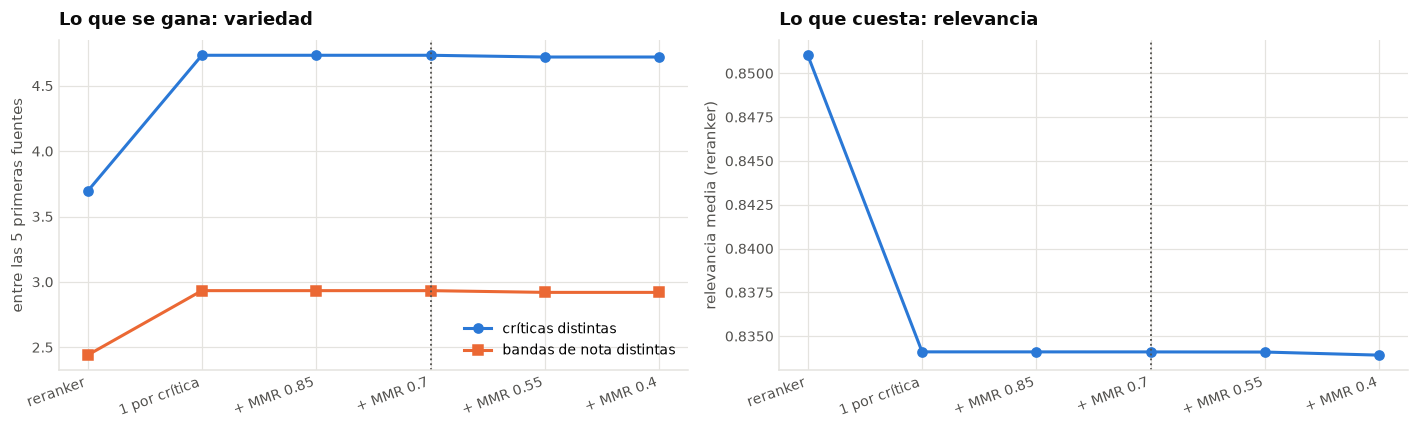

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.0, 4.0))
x = np.arange(len(ev_div))
elegida = list(ev_div.index).index(f"+ MMR {MMR_LAMBDA}")
ax1.plot(x, ev_div.criticas_distintas, marker="o", color=AZUL, lw=2, label="críticas distintas")
ax1.plot(x, ev_div.bandas_distintas, marker="s", color=NARANJA, lw=2, label="bandas de nota distintas")
ax1.axvline(elegida, color=TINTA_2, ls=":", lw=1.2)
ax1.set_xticks(x); ax1.set_xticklabels(ev_div.index, rotation=20, ha="right")
ax1.set_ylabel("entre las 5 primeras fuentes")
ax1.set_title("Lo que se gana: variedad")
ax1.legend(); ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

ax2.plot(x, ev_div.relevancia_media, marker="o", color=AZUL, lw=2)
ax2.axvline(elegida, color=TINTA_2, ls=":", lw=1.2)
ax2.set_xticks(x); ax2.set_xticklabels(ev_div.index, rotation=20, ha="right")
ax2.set_ylabel("relevancia media (reranker)")
ax2.set_title("Lo que cuesta: relevancia")
ax2.grid(); ax2.set_axisbelow(True); limpiar(ax2)
plt.tight_layout(); guardar(fig, "05-diversidad"); plt.show()

**Lo que vimos.** El orden del reranker, tal cual, mete de media **3,7 críticas distintas** en las cinco
primeras fuentes: más de una plaza se va en un segundo trozo de una crítica ya elegida. Una fuente por
crítica sube a **4,7** críticas y de 2,4 a 2,9 bandas de nota distintas, a cambio de bajar la relevancia
media de 0,85 a 0,83.

**MMR no añade nada encima**, con ningún λ, como se anticipaba: con la cabecera, todos los fragmentos de
una película se parecen entre sí casi por igual, y el término de "parecido" penaliza a todos los
candidatos lo mismo. La diversidad la da una regla sobre los metadatos, no la geometría del espacio. MMR
se queda en el sistema porque no cuesta nada, pero el trabajo lo hace la deduplicación.

### 6.6 La escalera, en test

La partición de prueba se toca **una vez**, con las decisiones ya tomadas. Cada peldaño añade una sola
pieza sobre el anterior: L6 cambia el troceado y el encoder por los elegidos en §6.4, L7 deja una fuente
por crítica y L8 activa MMR, que es la configuración con la que responde el chatbot. Al lado, **BM25
solo** (con cabecera), para la comparación de H3. L7 y L8 no buscan subir estas métricas sino variar las
fuentes: lo que se les pide aquí es que no las hundan.

| Peldaño | Troceado | Cabecera | Prefijos | Búsqueda | Reranker | Router | 1 por crítica | MMR |
|---|---|---|---|---|---|---|---|---|
| L0 · réplica del guía | palabras | – | – | densa | – | – | – | – |
| L1 | palabras | – | ✔ | densa | – | – | – | – |
| L2 | palabras | ✔ | ✔ | densa | – | – | – | – |
| L3 | palabras | ✔ | ✔ | híbrida | – | – | – | – |
| L4 | palabras | ✔ | ✔ | híbrida | ✔ | – | – | – |
| L5 | palabras | ✔ | ✔ | híbrida | ✔ | ✔ | – | – |
| L6 | elegido | ✔ | ✔ | híbrida | ✔ | ✔ | – | – |
| L7 | elegido | ✔ | ✔ | híbrida | ✔ | ✔ | ✔ | – |
| L8 · final | elegido | ✔ | ✔ | híbrida | ✔ | ✔ | ✔ | ✔ |

In [26]:
ESCALERA = [
    ("L0 · réplica del guía", dict(estrategia="palabras", con_cabecera=False, prefijo=False), dict(modo="denso", rerank=False)),
    ("L1 · + prefijos E5",    dict(estrategia="palabras", con_cabecera=False, prefijo=True),  dict(modo="denso", rerank=False)),
    ("L2 · + cabecera",       dict(estrategia="palabras", con_cabecera=True,  prefijo=True),  dict(modo="denso", rerank=False)),
    ("L3 · + BM25 (híbrida)", dict(estrategia="palabras", con_cabecera=True,  prefijo=True),  dict(modo="hibrido", rerank=False)),
    ("L4 · + reranker",       dict(estrategia="palabras", con_cabecera=True,  prefijo=True),  dict(modo="hibrido", rerank=True)),
    ("L5 · + router",         dict(estrategia="palabras", con_cabecera=True,  prefijo=True),  dict(modo="hibrido", rerank=True, router=True)),
    ("L6 · troceado y encoder de dev", dict(estrategia=TROCEADO, con_cabecera=True, prefijo=True, nombre=ENCODER_FINAL),
                              dict(modo="hibrido", rerank=True, router=True)),
    ("L7 · + 1 por crítica",  dict(estrategia=TROCEADO, con_cabecera=True, prefijo=True, nombre=ENCODER_FINAL),
                              dict(modo="hibrido", rerank=True, router=True, por_critica=True)),
    ("L8 · + MMR (final)",    dict(estrategia=TROCEADO, con_cabecera=True, prefijo=True, nombre=ENCODER_FINAL),
                              dict(modo="hibrido", rerank=True, router=True, por_critica=True, mmr=MMR_LAMBDA)),
]
PELDANOS = [n for n, _, _ in ESCALERA]
BM25_SOLO = "BM25 solo (con cabecera)"

evs = []
with medir("evaluación: escalera (test)"):
    for nombre, cfg_rec, cfg_bus in ESCALERA:
        evs.append(evaluar(rec_para(**cfg_rec), test, nombre, **cfg_bus))
    evs.append(evaluar(rec_para("palabras"), test, BM25_SOLO, modo="bm25", rerank=False))
ev_test = pd.concat(evs)
ev_test.to_csv(RES / f"recuperacion_test{SUFIJO}.csv", index=False)
guardar_memo()

print(tabla(ev_test).to_string())
print("\nsalto de cada peldaño (diferencia pareada ± desviación; * = supera 2 desviaciones):")
SALTOS = {}
for a, b in zip(PELDANOS[1:], PELDANOS[:-1]):
    celdas = []
    for f in FAMILIAS:
        d, sd = dif_pareada(ev_test, a, b, f)
        SALTOS[(a, f)] = (d, sd)
        celdas.append(f"{f} {d:+.3f} ± {sd:.3f}{'*' if abs(d) > 2 * sd else ' '}")
    print(f"  {a:<24} " + "   ".join(celdas))

   ⏱  evaluación: escalera (test): 0.4 min   (acumulado 1.1 min)
                               opinion · P@5 película trama · MRR@10 película aspecto · MRR@10 crítica
config                                                                                                
L0 · réplica del guía                   0.813 ± 0.030           0.564 ± 0.050            0.281 ± 0.045
L1 · + prefijos E5                      0.853 ± 0.027           0.609 ± 0.052            0.278 ± 0.045
L2 · + cabecera                         1.000 ± 0.000           0.581 ± 0.055            0.432 ± 0.044
L3 · + BM25 (híbrida)                   0.992 ± 0.008           0.805 ± 0.039            0.548 ± 0.047
L4 · + reranker                         0.997 ± 0.003           0.921 ± 0.030            0.561 ± 0.050
L5 · + router                           1.000 ± 0.000           0.908 ± 0.032            0.561 ± 0.050
L6 · troceado y encoder de dev          1.000 ± 0.000           0.935 ± 0.027            0.574 ± 0.048
L7 · + 1

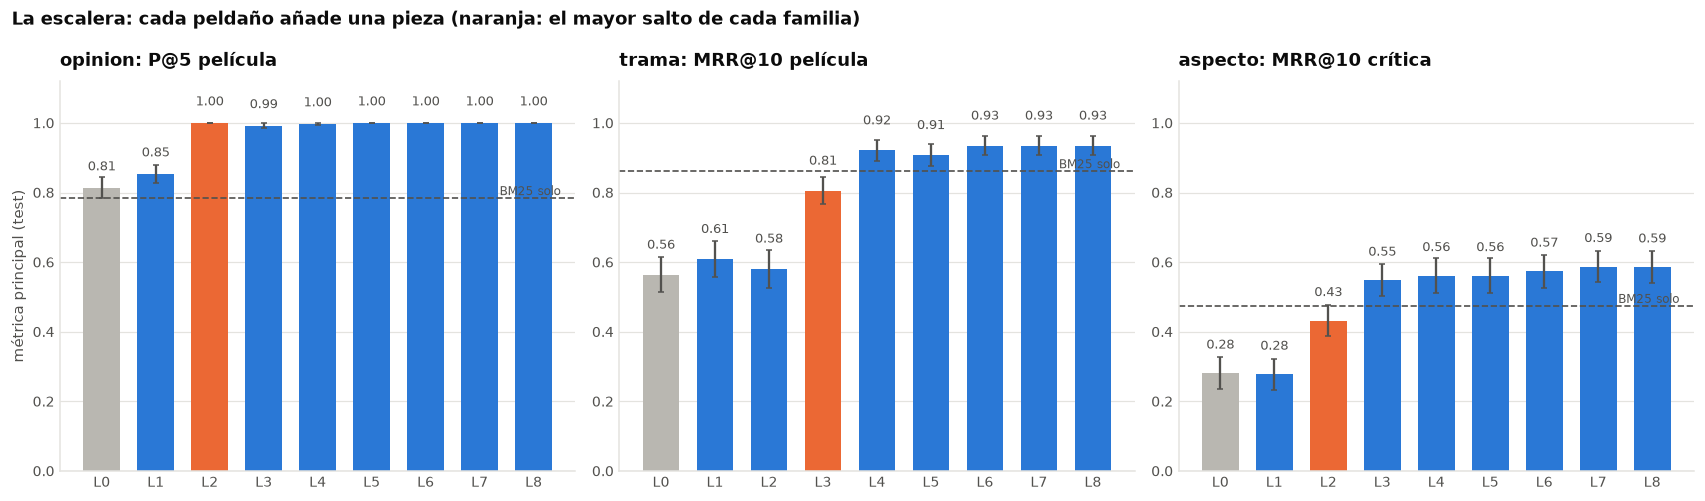

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(15.6, 4.6), sharey=False)
s = resumir(ev_test)
for ax, f in zip(axs, FAMILIAS):
    g = s[s.familia == f].set_index("config")
    vals = [g.loc[n, "media"] for n in PELDANOS]
    sds = [g.loc[n, "sd"] for n in PELDANOS]
    saltos = [SALTOS[(n, f)][0] for n in PELDANOS[1:]]
    mayor = 1 + int(np.argmax(saltos))
    colores = [GRIS_REAL] + [NARANJA if i == mayor else AZUL for i in range(1, len(PELDANOS))]
    ax.bar(range(len(PELDANOS)), vals, yerr=sds, color=colores, width=.68, ecolor=TINTA_2, capsize=2)
    for i, v in enumerate(vals):
        ax.text(i, v + max(sds) + .02, f"{v:.2f}", ha="center", fontsize=8.5, color=TINTA_2)
    ax.axhline(g.loc[BM25_SOLO, "media"], color=TINTA_2, ls="--", lw=1.1)
    ax.text(len(PELDANOS) - .5, g.loc[BM25_SOLO, "media"], " BM25 solo", fontsize=8, color=TINTA_2, va="bottom", ha="right")
    ax.set_xticks(range(len(PELDANOS))); ax.set_xticklabels([n.split(" · ")[0] for n in PELDANOS])
    ax.set_ylim(0, 1.12)
    ax.set_title(f"{f}: {PRINCIPAL[f][1]}")
    ax.grid(axis="y"); ax.set_axisbelow(True); limpiar(ax)
axs[0].set_ylabel("métrica principal (test)")
fig.suptitle("La escalera: cada peldaño añade una pieza (naranja: el mayor salto de cada familia)",
             x=0.01, ha="left", fontsize=12, fontweight="bold", color=TINTA)
plt.tight_layout(); guardar(fig, "06-escalera"); plt.show()

**Lo que vimos.** De la réplica del guía al sistema final, la métrica principal pasa de 0,81 a 1,00 en
opinión, de 0,56 a 0,94 en trama y de 0,28 a 0,59 en aspecto, más del doble. Pero cada familia la mueve
una pieza distinta, y eso es lo interesante:

- **Opinión la resuelve la cabecera** (+0,147, el único salto grande). Con ella, la P@5 llega a 1,00 y
  ya no se mueve. Los prefijos de E5 añaden +0,04: significativo, pero pequeño.
- **Trama la resuelven BM25 (+0,224) y el reranker (+0,116).** La cabecera no la ayuda (−0,03, dentro del
  ruido): quien describe la trama no nombra la película, así que repetir el título en cada fragmento no
  aporta nada. Lo inesperado es que **BM25 solo (0,861) le gana a la híbrida (0,805)** en trama. La fusión
  RRF le da el mismo peso a una lista densa bastante peor y la arrastra. Las peticiones de trama conservan
  palabras concretas de la sinopsis (*El Cairo*, *hipnosis*), justo lo que BM25 premia. Quien combina bien
  las dos listas es el reranker, que las relee con atención cruzada.
- **Aspecto sube con la cabecera (+0,154) y con BM25 (+0,116)**, y es la única familia donde la híbrida
  supera a sus dos partes. El reranker, en cambio, apenas suma aquí (+0,013, dentro del ruido): distinguir
  cuál de doce críticas de la misma película habla de la música es difícil también para él, y las
  preguntas genéricas del banco no ayudan.
- **El router no mueve estas métricas** (−0,014 en trama, nada en las otras): con la cabecera y el
  reranker, la película correcta ya estaba arriba. Su valor está en la generación. Garantiza que todas
  las fuentes sean de la película preguntada y habilita el filtro por nota y la memoria (§8–9).
- El troceado y el encoder elegidos en dev (+0,03 en trama, +0,01 en aspecto) y una fuente por crítica
  (+0,013 en aspecto, significativo) suman poco, pero suman. MMR, nada.

### 6.7 ¿Hace falta un índice aproximado?

El guía 2 usa FAISS. Con unos 30.000 vectores, la búsqueda exacta (un producto de matrices) ya es
instantánea; FAISS importa cuando el índice crece. Comparamos la búsqueda exacta con un índice **HNSW**
(Malkov y Yashunin, 2018), el grafo aproximado más usado: cuánto se gana en tiempo y cuánto se pierde
de los 10 primeros resultados exactos.

In [28]:
Qt = embeber_consultas(test.pregunta, rec_final.nombre)
E = rec_final.E
d = E.shape[1]

def por_consulta(fn, reps=3):
    t0 = time.perf_counter()
    for _ in range(reps):
        out = fn()
    return out, 1000 * (time.perf_counter() - t0) / (reps * len(Qt))

I_np, ms_np = por_consulta(lambda: np.argsort(-(Qt @ E.T), axis=1)[:, :10])
plano = faiss.IndexFlatIP(d); plano.add(E)
(_, I_plano), ms_plano = por_consulta(lambda: plano.search(Qt, 10))
t0 = time.perf_counter()
hnsw = faiss.IndexHNSWFlat(d, 32, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 80
hnsw.add(E)
seg_hnsw = time.perf_counter() - t0
hnsw.hnsw.efSearch = 64
(_, I_hnsw), ms_hnsw = por_consulta(lambda: hnsw.search(Qt, 10))
recall = np.mean([len(set(a) & set(b)) / 10 for a, b in zip(I_hnsw, I_plano)])

print(f"{len(E):,} vectores de {d} dimensiones ({E.nbytes/1e6:.0f} MB)\n")
print(pd.DataFrame({
    "ms por consulta": [ms_np, ms_plano, ms_hnsw],
    "recall@10 frente a exacto": [1.0, 1.0, recall],
    "construcción (s)": [0, 0, seg_hnsw]},
    index=["numpy (exacto)", "FAISS plano (exacto)", "FAISS HNSW (aproximado)"]).round(3).to_string())
escala = len(criticas) / len(resenas)
print(f"\ncon las {len(criticas):,} críticas del corpus serían ~{len(E) * escala / 1e6:.1f} M vectores y "
      f"~{E.nbytes * escala / 1e9:.0f} GB en float32")

29,858 vectores de 768 dimensiones (92 MB)

                         ms por consulta  recall@10 frente a exacto  construcción (s)
numpy (exacto)                     1.035                      1.000             0.000
FAISS plano (exacto)               0.290                      1.000             0.000
FAISS HNSW (aproximado)            0.050                      0.931             1.549

con las 419,827 críticas del corpus serían ~2.1 M vectores y ~6 GB en float32


**Lo que vimos.** Con 29.858 vectores de 768 dimensiones (92 MB), la búsqueda exacta tarda 5,7 ms por
consulta con numpy y 2,4 ms con FAISS plano. HNSW baja a 0,35 ms, dieciséis veces menos que numpy, pero
pierde un 7 % de los diez primeros resultados (recall@10 de 0,93) y tarda 13 s en construirse. A este
tamaño no compensa, porque el cuello de botella del chatbot es el LLM, que tarda segundos. Con el corpus
completo serían unos 2 millones de vectores y 6 GB, y ahí un índice aproximado o cuantizado dejaría de
ser opcional.

---

## 7. El espacio de *embeddings*, con y sin cabecera

La escalera dice **cuánto** ayuda la cabecera. Esta figura enseña **por qué**. Tomamos los fragmentos
de crítica de ocho películas populares y los proyectamos a dos dimensiones con t-SNE, sin cabecera y
con ella. El coeficiente de silueta, calculado en el espacio original de 1.024 dimensiones, mide si los
fragmentos de una misma película quedan más cerca entre sí que de los de otras. Va de −1 a 1, y 0
significa que no hay grupos.

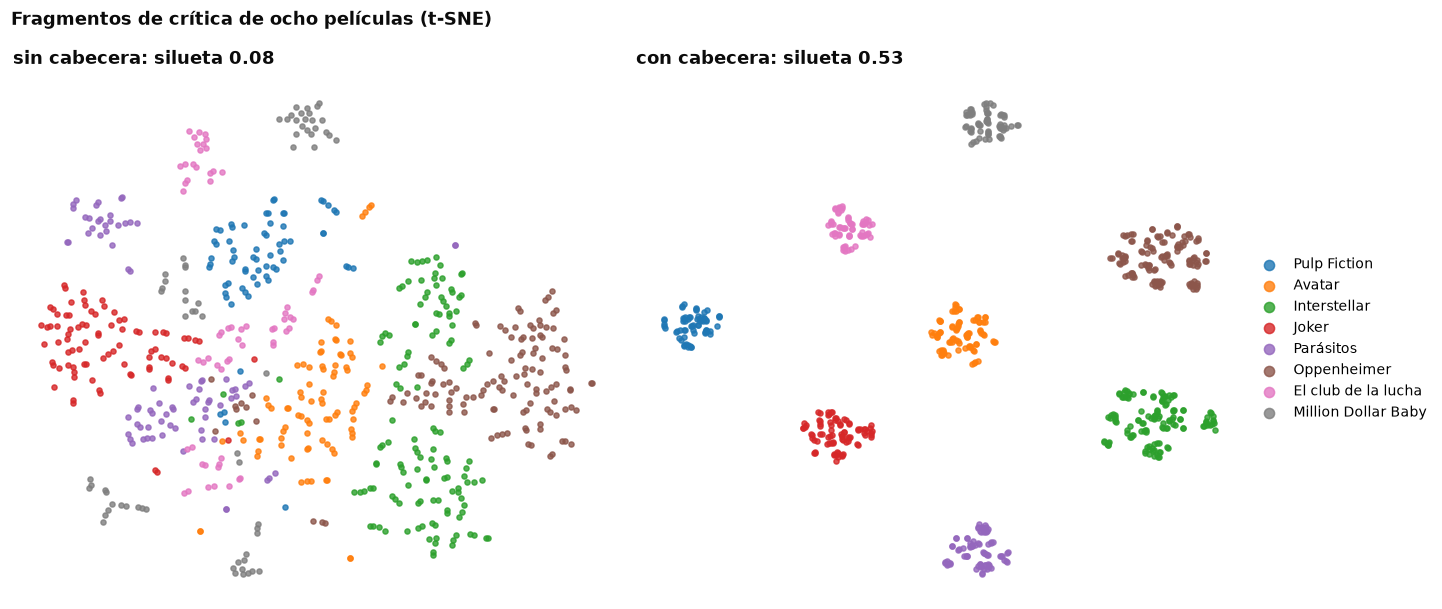

{'sin cabecera': 0.08, 'con cabecera': 0.531}


In [29]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

demo_ids = [f for f, p in P.iterrows() if (p.film_title, p.film_year) in set(DEMO)][:6]
ocho = demo_ids + [f for f in catalogo[catalogo.quintil == 5].film_id if f not in demo_ids][:8 - len(demo_ids)]
docs_p = DOCS["palabras"]
idx = np.flatnonzero((docs_p.tipo == "critica").values & docs_p.film_id.isin(ocho).values)
etiquetas = docs_p.film_id.values[idx]

fig, axs = plt.subplots(1, 2, figsize=(13.2, 5.6))
paleta = mpl.colormaps["tab10"]
SILUETA = {}
for ax, (titulo, rec) in zip(axs, [("sin cabecera", rec_para("palabras", False, True)),
                                   ("con cabecera", rec_para("palabras", True, True))]):
    X = rec.E[idx]
    SILUETA[titulo] = silhouette_score(X, etiquetas, metric="cosine")
    Y = TSNE(n_components=2, metric="cosine", init="pca", perplexity=min(30, len(idx) // 4),
             random_state=SEED).fit_transform(X)
    for j, f in enumerate(ocho):
        m = etiquetas == f
        ax.scatter(Y[m, 0], Y[m, 1], s=11, color=paleta(j), alpha=.8,
                   label=titulo_corto(P.loc[f].film_title)[:22])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{titulo}: silueta {SILUETA[titulo]:.2f}")
    limpiar(ax, ("top", "right", "left", "bottom"))
axs[1].legend(loc="center left", bbox_to_anchor=(1.0, .5), markerscale=2)
fig.suptitle("Fragmentos de crítica de ocho películas (t-SNE)", x=.01, ha="left",
             fontsize=12, fontweight="bold", color=TINTA)
plt.tight_layout(); guardar(fig, "07-embeddings-cabecera"); plt.show()
print({k: round(v, 3) for k, v in SILUETA.items()})

**Lo que vimos.** Sin cabecera, los fragmentos de ocho películas populares forman una nube con zonas más
densas pero mezcladas (silueta 0,08, prácticamente sin grupos). Con cabecera se separan en ocho grupos
limpios (silueta 0,53). Es la imagen de H1: la cabecera mete en cada vector "de qué película hablo", que
el texto de la crítica casi nunca dice.

La otra cara también se ve: dentro de cada grupo los fragmentos quedan tan juntos que la geometría deja
de distinguir una crítica de otra. Por eso MMR no hizo nada en §6.5, y por eso la familia *aspecto*,
que pide encontrar una crítica concreta entre las de su película, es la que menos sube.

---

## 8. Generación

### 8.1 El *prompt* y las citas

El guía le pide al modelo que **simule** que ya conocía la información (*"No menciones que te he
proporcionado fragmentos"*). Para un chatbot de opiniones es justo lo contrario de lo que queremos: cada
afirmación tiene que poder rastrearse hasta una crítica. Por eso las fuentes van **numeradas**, con su
tipo y su nota, y el *prompt* exige citar `[n]`, atribuir las opiniones y, si las fuentes no tratan lo
preguntado, responder una frase fija. Esa frase fija es la que §8.3 cuenta como abstención.

Dos ajustes salieron de mirar respuestas reales. **La ficha se fija**: si el router reconoce una
película (o, si no, la de la mejor fuente), su ficha entra siempre entre las fuentes. Sin eso, a
*"¿Quién dirigió Parásitos y dónde verla?"* el reranker prefería críticas y el modelo contestaba de
memoria. **Las fuentes se agrupan por película**, la ficha delante: con las fuentes mezcladas, a una
pregunta de trama el modelo eligió la única ficha que vio arriba aunque las críticas mejor puntuadas
fueran de otra película.

Cuando el router filtra por nota, el *prompt* lo dice. Sin ese aviso, a *"¿qué le critican los que le
pusieron mala nota?"* el modelo resumía bien las críticas de 1–4 y concluía *"en general, la opinión de
los espectadores sobre Joker es muy negativa"*: no sabía que le habíamos escondido las demás.

Dos salidas **no pasan por el LLM**: la de la compuerta de §8.3 y la de un filtro de nota que deja sin
críticas (*"¿qué dicen los que le pusieron mala nota?"* a una película sin críticas negativas en el
catálogo). En la prueba de humo, sin esta segunda salida, el modelo recibió sólo la ficha y se inventó
una crítica de 2/10 con citas a fuentes que no existían. El verificador de citas de `con_fuentes()`
avisa además de cualquier `[n]` que no corresponda a una fuente.

La memoria funciona como la que el guía quería tener: si hay historial, el LLM reescribe la pregunta
nueva para que se entienda sola (*"¿y los que le pusieron mala nota?"* → *"¿Qué critican de Joker
los que le pusieron mala nota?"*), y esa pregunta reescrita es la que pasa por el router y el
recuperador. En la primera corrida completa la reescritura falló: con las respuestas anteriores delante,
el modelo de 3B reescribió sobre lo último que había leído y perdió la película y la nota. Ahora el LLM
sólo ve las preguntas anteriores y la película de la que se hablaba, y el router tiene su propia
memoria: lee también la pregunta original y, si es de seguimiento (*"y…"*, *"los que…"*), hereda la
película del turno anterior. Y **sólo se reescriben las preguntas de seguimiento**. Probando la interfaz,
después de dos preguntas sobre *Oppenheimer*, el modelo reescribió una pregunta nueva, *"Busco una
película de supervivencia en la nieve basada en hechos reales"*, como *"¿Qué opinan los espectadores de
Arktos?"*, un título que no está en el catálogo. Una pregunta que no señala nada anterior ya no pasa por el LLM.

In [30]:
NO_SE = "No tengo críticas sobre eso en mi catálogo."
RANGO = {NEG: "1–4", MED: "5–6", POS: "7–10"}

SISTEMA = """Eres CineRAG, un asistente que responde preguntas sobre películas usando EXCLUSIVAMENTE las fuentes numeradas que recibes: fichas de FilmAffinity y críticas escritas por usuarios.

Reglas:
1. Responde en español, en un párrafo de 3 a 6 frases.
2. Después de cada afirmación escribe entre corchetes el número de la fuente que la respalda, por ejemplo [2]. Usa solo números de fuentes que existan.
3. Las críticas son opiniones de usuarios: atribúyelas («un espectador que le pone 9/10 destaca…») y, si hay opiniones opuestas, muestra las dos.
4. Si las fuentes no hablan de la película o del tema preguntado, responde únicamente: «No tengo críticas sobre eso en mi catálogo.» No completes con lo que sepas por tu cuenta.
5. No reveles giros de la trama de las fuentes marcadas como spoiler salvo que te lo pidan."""

REFORMULAR = """Reescribe la última pregunta del usuario para que se entienda sola, sin el historial. Sustituye las referencias implícitas («y los que…», «esa», «la anterior») por el título de la película de la que se hablaba, y conserva todo lo demás que pide la pregunta (notas, aspectos, spoilers). Si ya se entiende sola, devuélvela igual. Responde solo con la pregunta reescrita.

Preguntas anteriores del usuario:
{historial}
Película de la que se hablaba: {pelicula}

Última pregunta: {pregunta}
Pregunta reescrita:"""

# Una pregunta de seguimiento: empieza por "y", "pero"… o señala algo ya dicho ("los que…", "¿dónde la
# puedo ver?", "su director"). Sólo esas se reescriben y heredan la película del turno anterior.
SEGUIMIENTO = re.compile(r"^(y|e|pero|entonces|tambien|ademas)\b|\b(esa|ese|ella|aquella|los que|las que)\b"
                         r"|\b(la|lo) (puedo|puede|pueden|recomiendas|recomiendan)\b"
                         r"|\bsu (director|directora|final|musica|banda sonora|reparto|guion|fotografia)\b")

def etiqueta_fuente(d):
    p = P.loc[d.film_id]
    if d.tipo == "ficha":
        return f"Ficha de «{p.film_title}» ({p.film_year})"
    clase = "Spoiler de una crítica de usuario" if d.tipo == "spoiler" else "Crítica de usuario"
    return f"{clase} de «{p.film_title}» ({p.film_year}), nota {int(d.nota)}/10"

def mensajes_rag(pregunta, fuentes, filtros=None):
    bloques = "\n\n".join(f"[{n}] {etiqueta_fuente(d)}\n{d.cuerpo}"
                          for n, d in enumerate(fuentes.itertuples(), 1))
    aviso = ""
    if filtros and filtros.get("notas") is not None:
        # Sin este aviso, con las críticas filtradas el modelo concluía "la opinión general es muy negativa".
        aviso = (f"(Las críticas se filtraron: sólo están las de nota {RANGO[filtros['notas']]}. "
                 f"No las presentes como la opinión de todos los espectadores.)\n\n")
    return [{"role": "system", "content": SISTEMA},
            {"role": "user", "content": f"Fuentes:\n\n{bloques}\n\n{aviso}Pregunta: {pregunta}"}]

CITA = re.compile(r"\[(\d+(?:\s*[,;–-]\s*\d+)*)\]")
def citas(texto):
    nums = []
    for grupo in CITA.findall(texto):
        for parte in re.split(r"\s*[,;]\s*", grupo):
            extremos = [int(x) for x in re.split(r"\s*[–-]\s*", parte) if x]
            if len(extremos) == 2 and 0 < extremos[1] - extremos[0] < 10:
                nums += list(range(extremos[0], extremos[1] + 1))
            else:
                nums += extremos
    return sorted(set(nums))

ABSTIENE = re.compile(r"no tengo (criticas|informacion|datos|constancia)|no (dispongo|encuentro|conozco)|"
                      r"no puedo (responder|ayudar|proporcionar|darte)|no hay (criticas|informacion|datos)|"
                      r"desconozco|no se (de|sobre|nada|quien)|no estoy (familiarizad|segur)|"
                      r"no (existe|aparece|figura)|no se (menciona|encuentra)")
def empieza_negando(texto):
    # "No tengo información…" al principio; "no hay críticas negativas" más adelante no cuenta.
    return bool(ABSTIENE.search(norm(texto)[:160]))

def se_abstiene(texto, max_palabras=60):
    # Abstenerse es decir que no se sabe y detenerse. A libro cerrado, el 3B suele empezar con
    # "No tengo información…" y seguir con 200 palabras inventadas: eso no cuenta como abstención.
    return empieza_negando(texto) and len(texto.split()) <= max_palabras


class CineRAG:

    def __init__(self, rec, llm, k=6, modo="hibrido", rerank=True, mmr=MMR_LAMBDA, por_critica=True, umbral=None):
        self.rec, self.llm = rec, llm
        self.ajustes = dict(k=k, modo=modo, rerank=rerank, mmr=mmr, por_critica=por_critica)
        self.umbral = umbral
        self.historial = []

    def reset(self):
        self.historial.clear()

    def reformular(self, pregunta):
        # Al LLM sólo se le dan las preguntas anteriores y la película: con las respuestas completas
        # delante, el modelo de 3B reescribía sobre lo último que había leído y perdía la película.
        if not self.historial or not SEGUIMIENTO.search(norm(pregunta)):
            return pregunta
        hist = "\n".join(f"- {h['pregunta']}" for h in self.historial[-3:])
        ultima = next((h["film_ids"] for h in reversed(self.historial) if h["film_ids"]), None)
        pelicula = f"{P.loc[ultima[0]].film_title} ({P.loc[ultima[0]].film_year})" if ultima else "ninguna"
        salida = limpiar_salida(self.llm.completion(
            REFORMULAR.format(historial=hist, pelicula=pelicula, pregunta=pregunta)))
        return salida if len(salida.split()) >= 3 else pregunta

    def preparar(self, pregunta, notas="auto", spoilers=None, **ajustes):
        consulta = self.reformular(pregunta)
        filtros, original = analizar(consulta), analizar(pregunta)
        # Lo que el router lee en la pregunta original también vale: la reformulación puede perderlo.
        filtros["notas"] = filtros["notas"] or original["notas"]
        filtros["spoilers"] = filtros["spoilers"] or original["spoilers"]
        filtros["film_ids"] = filtros["film_ids"] or original["film_ids"]
        if filtros["film_ids"] is None and self.historial and SEGUIMIENTO.search(norm(pregunta)):
            filtros["film_ids"] = self.historial[-1]["film_ids"]       # memoria del router
        if notas != "auto":
            filtros["notas"] = notas
        if spoilers is not None:
            filtros["spoilers"] = spoilers or filtros["spoilers"]
        a = {**self.ajustes, **ajustes}
        fuentes = self.rec.buscar(consulta, **a, **filtros)
        tope = float(fuentes.relevancia.max()) if ("relevancia" in fuentes and len(fuentes)) else None
        if len(fuentes):
            fuentes = self.anclar_ficha(consulta, fuentes, filtros["film_ids"], a["k"])
        # La compuerta sólo actúa si el router no reconoció ninguna película del catálogo.
        compuerta = (self.umbral is not None and filtros["film_ids"] is None
                     and tope is not None and tope < self.umbral) or fuentes.empty
        fija = NO_SE if compuerta else None
        if fija is None and filtros["notas"] is not None and not (fuentes.tipo != "ficha").any():
            # El filtro de nota dejó sólo la ficha: sin esta salida, el LLM se inventa la crítica que falta.
            peli = f"«{P.loc[filtros['film_ids'][0]].film_title}»" if filtros["film_ids"] else "eso"
            fija = f"Entre las críticas de {peli} que tengo no hay ninguna con nota {RANGO[filtros['notas']]}."
        return {"pregunta": pregunta, "consulta": consulta, "filtros": filtros, "fuentes": fuentes,
                "tope": tope, "compuerta": compuerta, "fija": fija}

    def anclar_ficha(self, consulta, fuentes, film_ids, k):
        # La ficha de la película reconocida (o de la mejor fuente) entra siempre, y las fuentes se agrupan
        # por película: primero la ficha, luego sus críticas, en el orden de su mejor fragmento.
        ancla = film_ids[0] if film_ids else fuentes.iloc[0].film_id
        docs = self.rec.docs
        if not ((fuentes.film_id == ancla) & (fuentes.tipo == "ficha")).any():
            ficha = docs[(docs.film_id == ancla) & (docs.tipo == "ficha")]
            if "relevancia" in fuentes:
                ficha = ficha.assign(relevancia=relevancia(consulta, [self.rec.textos[i] for i in ficha.index]))
            fuentes = pd.concat([fuentes.iloc[:k - len(ficha)], ficha])
        orden = {f: i for i, f in enumerate(pd.unique(fuentes.film_id))}
        clave = fuentes.film_id.map(orden) * 2 + (fuentes.tipo != "ficha")
        return fuentes.iloc[np.argsort(clave.values, kind="stable")]

    def __call__(self, pregunta, guardar=True, memo=True, **opciones):
        e = self.preparar(pregunta, **opciones)
        e["respuesta"] = e["fija"] or self.llm.completion(
            mensajes_rag(e["consulta"], e["fuentes"], e["filtros"]), memo=memo).strip()
        e["citas"] = citas(e["respuesta"])
        if guardar:
            self.historial.append({"pregunta": pregunta, "respuesta": e["respuesta"],
                                   "film_ids": e["filtros"]["film_ids"]})
        return e

    def responder_stream(self, pregunta, **opciones):
        e = self.preparar(pregunta, **opciones)
        if e["fija"]:
            e["respuesta"] = e["fija"]
        else:
            e["respuesta"] = ""
            for trozo in self.llm.completion_stream(mensajes_rag(e["consulta"], e["fuentes"], e["filtros"])):
                e["respuesta"] += trozo
                yield e["respuesta"], e
        e["citas"] = citas(e["respuesta"])
        self.historial.append({"pregunta": pregunta, "respuesta": e["respuesta"],
                               "film_ids": e["filtros"]["film_ids"]})
        yield con_fuentes(e), e


def con_fuentes(e):
    # La respuesta y, debajo, las fuentes que citó (o todas, si no citó ninguna), con enlace a FilmAffinity.
    r = e["respuesta"]
    if e["compuerta"]:
        if len(e["fuentes"]):
            d = e["fuentes"].iloc[0]
            r += (f"\n\n*(Lo más cercano en el catálogo era «{P.loc[d.film_id].film_title}», "
                  f"con relevancia {e['tope']:.2f}.)*")
        return r
    if e["fija"]:
        return r
    usadas = [n for n in e["citas"] if 1 <= n <= len(e["fuentes"])]
    invalidas = [n for n in e["citas"] if not 1 <= n <= len(e["fuentes"])]
    lineas = []
    for n, d in enumerate(e["fuentes"].itertuples(), 1):
        if usadas and n not in usadas:
            continue
        p = P.loc[d.film_id]
        url = f"https://www.filmaffinity.com/es/{d.film_id}.html"
        if d.tipo == "ficha":
            desc = "ficha de la película"
        else:
            desc = f"{'spoiler de una crítica' if d.tipo == 'spoiler' else 'crítica de usuario'}, nota {int(d.nota)}/10"
            if d.titulo_critica:
                desc += f" · «{d.titulo_critica}»"
        lineas.append(f"- **[{n}]** [{p.film_title} ({p.film_year})]({url}) — {desc}")
    titulo = ("Fuentes citadas" if usadas else
              "Fuentes consultadas (la respuesta no citó ninguna válida)" if invalidas else
              "Fuentes consultadas (la respuesta no citó ninguna)")
    aviso = (f"\n\n⚠ La respuesta cita {', '.join(f'[{n}]' for n in invalidas)}, que no existe entre las fuentes."
             if invalidas else "")
    return f"{r}{aviso}\n\n**{titulo}**\n" + "\n".join(lineas)

**¿Cómo se le pide que cite?** El modelo de 3B obedece la regla de citar, pero tiende a amontonar todas
las citas al final (*"…[1], [2], [3], [4]"*), y así no se sabe qué fuente respalda qué frase. Probamos
tres redacciones de la regla 2 sobre 38 preguntas: 15 de opinión y 15 de trama de **dev**, y las 8 de la
demo. La regla, escrita antes de mirar: **entre las redacciones que citan alguna fuente en al menos el
90 % de las respuestas, la que más cita dentro del texto.**

Dos tropiezos de las primeras versiones explican la forma de la redacción C. Un ejemplo con contenido
(*"…elogian la fotografía [2]"*) se **filtraba** a las respuestas: el modelo llegó a escribir "Destaca la
fotografía [1]" sobre una película cuya fuente no hablaba de fotografía. Por eso su ejemplo no dice nada.
Y una prueba con sólo ocho preguntas eligió una redacción que en test dejaba sin citar una de cada cuatro
respuestas de opinión: de ahí las 38.

In [31]:
PRUEBA_CITAS = (["¿Qué opinan los espectadores de Joker?", "¿Vale la pena ver Oppenheimer?", "¿Por qué critican Avatar?",
                 "¿Qué dicen de la banda sonora de Interstellar?", "¿Quién dirigió Parásitos y dónde la puedo ver?",
                 "Busco una película de supervivencia en la nieve basada en hechos reales",
                 "¿Qué es lo que más gusta de Pulp Fiction?", "¿Qué le critican a Joker los que le pusieron mala nota?"]
                + dev[dev.familia == "opinion"].sample(min(15, (dev.familia == "opinion").sum()), random_state=SEED).pregunta.tolist()
                + dev[dev.familia == "trama"].sample(min(15, (dev.familia == "trama").sum()), random_state=SEED).pregunta.tolist())
REGLA_A = SISTEMA.split("\n")[3]
REGLAS = {
    "A · después de cada afirmación": REGLA_A,
    "B · A + «no todas al final»": REGLA_A + " Pon cada cita junto a la frase que respalda, no todas al final.",
    "C · cada frase termina con su cita": "2. Termina cada frase con el número de la fuente que la respalda, entre "
                                          "corchetes y justo antes del punto: «… [2].» Usa solo números de fuentes que existan.",
}

def cita_en_cuerpo(texto):
    # ¿Queda alguna cita al quitar el bloque de citas del final?
    resto = re.sub(r"(\s*\[\d+(?:\s*[,;–-]\s*\d+)*\][\s,.;]*)+$", "", texto.strip())
    return bool(CITA.search(resto))

base = SISTEMA
filas = []
with medir("§8.1 redacción de la regla de citas"):
    for nombre, regla in REGLAS.items():
        SISTEMA = base.replace(REGLA_A, regla)
        prueba = CineRAG(rec_final, llm)
        for q in PRUEBA_CITAS:
            e = prueba(q, guardar=False)
            filas.append({"regla": nombre,
                          "cita alguna fuente": any(1 <= n <= len(e["fuentes"]) for n in e["citas"]),
                          "cita dentro del texto": cita_en_cuerpo(e["respuesta"])})
guardar_memo()
t = pd.DataFrame(filas).groupby("regla", sort=False).mean()
aptas = t[t["cita alguna fuente"] >= 0.9]
REGLA_ELEGIDA = (aptas["cita dentro del texto"].idxmax() if len(aptas) else t["cita alguna fuente"].idxmax())
SISTEMA = base.replace(REGLA_A, REGLAS[REGLA_ELEGIDA])
print(t.round(2).to_string())
print(f"\n{len(PRUEBA_CITAS)} preguntas · → regla elegida: {REGLA_ELEGIDA}\n")

e = CineRAG(rec_final, llm)("¿Qué opinan los espectadores de Pulp Fiction?", guardar=False)
print(con_fuentes(e))

   ⏱  §8.1 redacción de la regla de citas: 0.1 min   (acumulado 1.1 min)
                                    cita alguna fuente  cita dentro del texto
regla                                                                        
A · después de cada afirmación                    0.89                   0.21
B · A + «no todas al final»                       0.95                   0.42
C · cada frase termina con su cita                0.82                   0.37

38 preguntas · → regla elegida: B · A + «no todas al final»

La opinión de los espectadores sobre Pulp Fiction es muy variada. Algunos, como el usuario que le dio una nota de 4/10, consideran que la película es "vacía y hueca" y que no tiene un contenido intenso o significativo. Por otro lado, otros espectadores, como el que le dio una nota de 9/10, destacan la genialidad de la película y su capacidad para crear una atmósfera única y emocionante. También hay opiniones que destacan la habilidad de Tarantino para crear situaciones g

### 8.2 ¿Inventa sin RAG? Directores por popularidad, y cuánto modelo hace falta

Una pregunta con respuesta exacta y comprobable: *"¿Quién dirigió la película «…» (año)?"*, sobre 100
películas del catálogo, 20 por quintil de popularidad. Cuatro condiciones: `llama3.2:3b` y
`llama3.2:1b`, cada uno **a libro cerrado** (sólo la pregunta) y **con RAG** (CineRAG completo, con la
ficha entre las fuentes).

Se cuenta como acierto que el apellido de algún director aparezca en la respuesta. Una respuesta que
no acierta puede ser de dos tipos y los separamos: **se abstiene** (empieza diciendo que no sabe y se
detiene, en 60 palabras o menos) o **inventa** (da otro nombre). Lo segundo es la alucinación de
memoria de la clase teórica.

In [32]:
N_DIR = 20 if HUMO else 100
PREG_DIR = "¿Quién dirigió la película «{t}» ({a})? Responde solo con el nombre del director."

def acierta(respuesta, directores):
    r = f" {norm(respuesta)} "
    return any(f" {norm(d).split()[-1]} " in r for d in directores if norm(d))

muestra_dir = (catalogo[catalogo.film_director.str.len() > 0]
               .groupby("quintil").sample(N_DIR // 5, random_state=SEED + 3))
rag_3b, rag_1b = CineRAG(rec_final, llm), CineRAG(rec_final, llm_peq)
filas = []
with medir("§8.2 directores: 4 condiciones"):
    for p in muestra_dir.itertuples():
        preg = PREG_DIR.format(t=titulo_corto(p.film_title), a=p.film_year)
        for etiqueta, modelo, rag in [("3B", llm, rag_3b), ("1B", llm_peq, rag_1b)]:
            for condicion, resp in [("libro cerrado", modelo.completion(preg)),
                                    ("RAG", rag(preg, guardar=False)["respuesta"])]:
                filas.append(dict(film_id=p.film_id, titulo=p.film_title, quintil=p.quintil,
                                  modelo=etiqueta, condicion=condicion, respuesta=resp.strip(),
                                  director=", ".join(p.film_director),
                                  acierto=acierta(resp, p.film_director), abstiene=se_abstiene(resp)))
guardar_memo()
dirs = pd.DataFrame(filas)
dirs["inventa"] = ~dirs.acierto & ~dirs.abstiene
dirs.to_csv(RES / f"directores{SUFIJO}.csv", index=False)

t = dirs.pivot_table(index=["modelo", "condicion"], columns="quintil", values="acierto", aggfunc="mean")
t["total"] = dirs.groupby(["modelo", "condicion"]).acierto.mean()
print("acierto por quintil de popularidad (1 = menos popular):")
print(t.round(2).to_string())
print("\nreparto de las respuestas:")
print(dirs.groupby(["modelo", "condicion"])[["acierto", "abstiene", "inventa"]].mean().round(2).to_string())
print("\nejemplos de alucinación de 3B a libro cerrado:")
for _, r in dirs[(dirs.modelo == "3B") & (dirs.condicion == "libro cerrado") & dirs.inventa] \
        .sort_values("quintil").head(6).iterrows():
    print(f"  q{r.quintil}  {r.titulo[:30]:<30} real: {r.director[:26]:<26} → {r.respuesta[:45]!r}")

   ⏱  §8.2 directores: 4 condiciones: 0.1 min   (acumulado 1.3 min)
acierto por quintil de popularidad (1 = menos popular):
quintil                  1     2     3     4     5  total
modelo condicion                                         
1B     RAG            1.00  0.95  1.00  1.00  1.00   0.99
       libro cerrado  0.05  0.00  0.05  0.00  0.15   0.05
3B     RAG            1.00  1.00  1.00  1.00  1.00   1.00
       libro cerrado  0.10  0.25  0.15  0.35  0.35   0.24

reparto de las respuestas:
                      acierto  abstiene  inventa
modelo condicion                                
1B     RAG               0.99      0.01     0.00
       libro cerrado     0.05      0.05     0.90
3B     RAG               1.00      0.00     0.00
       libro cerrado     0.24      0.25     0.51

ejemplos de alucinación de 3B a libro cerrado:
  q1  Pura formalidad                real: Giuseppe Tornatore         → 'Pedro Almodóvar.'
  q1  Mejor otro día                 real: Pascal Chaumeil         

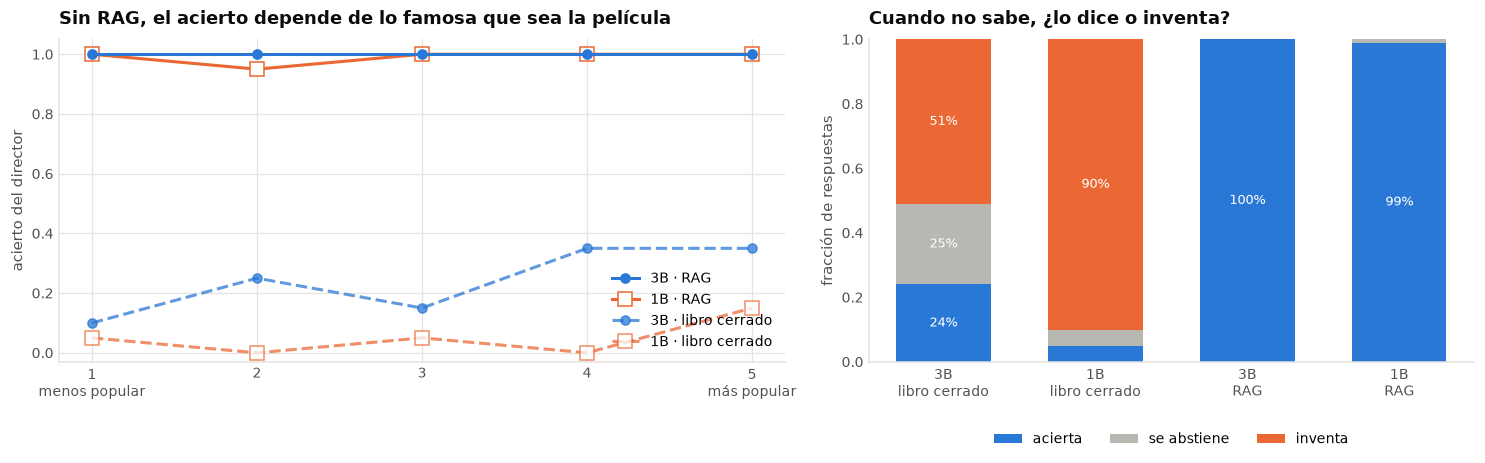

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.6, 4.4), gridspec_kw={"width_ratios": [1.2, 1]})
estilos = {("3B", "RAG"): (AZUL, "-", "o"), ("1B", "RAG"): (NARANJA, "-", "s"),
           ("3B", "libro cerrado"): (AZUL, "--", "o"), ("1B", "libro cerrado"): (NARANJA, "--", "s")}
for (m, c), (color, ls, mk) in estilos.items():
    g = dirs[(dirs.modelo == m) & (dirs.condicion == c)].groupby("quintil").acierto.mean()
    ax1.plot(g.index, g.values, color=color, ls=ls, marker=mk, lw=2, label=f"{m} · {c}",
             alpha=1 if c == "RAG" else .75, ms=9 if m == "1B" else 6,
             mfc="white" if m == "1B" else color, zorder=3 if m == "3B" else 2)
ax1.set_xticks(range(1, 6)); ax1.set_xticklabels(["1\nmenos popular", "2", "3", "4", "5\nmás popular"])
ax1.set_ylim(-.03, 1.05); ax1.set_ylabel("acierto del director")
ax1.set_title("Sin RAG, el acierto depende de lo famosa que sea la película")
ax1.legend(loc="lower right"); ax1.grid(); ax1.set_axisbelow(True); limpiar(ax1)

orden = [("3B", "libro cerrado"), ("1B", "libro cerrado"), ("3B", "RAG"), ("1B", "RAG")]
r = dirs.groupby(["modelo", "condicion"])[["acierto", "abstiene", "inventa"]].mean()
abajo = np.zeros(len(orden))
for col, color, nombre in [("acierto", AZUL, "acierta"), ("abstiene", GRIS_REAL, "se abstiene"),
                           ("inventa", NARANJA, "inventa")]:
    v = np.array([r.loc[o, col] for o in orden])
    ax2.bar(range(len(orden)), v, bottom=abajo, color=color, width=.62, label=nombre)
    for i, (b, h) in enumerate(zip(abajo, v)):
        if h > .06:
            ax2.text(i, b + h / 2, f"{h:.0%}", ha="center", va="center", fontsize=8.5, color="white")
    abajo += v
ax2.set_xticks(range(len(orden))); ax2.set_xticklabels([f"{m}\n{c}" for m, c in orden])
ax2.set_ylim(0, 1); ax2.set_ylabel("fracción de respuestas")
ax2.set_title("Cuando no sabe, ¿lo dice o inventa?")
ax2.legend(loc="upper center", bbox_to_anchor=(.5, -.18), ncol=3); limpiar(ax2)
plt.tight_layout(); guardar(fig, "08-alucinacion"); plt.show()

**Lo que vimos.** A libro cerrado, `llama3.2:3b` acierta el director en el **24 %** de las películas,
dice que no lo sabe en el 25 % e **inventa en el 51 %**: *Pura formalidad* (Tornatore) pasa a ser de
Almodóvar, *La vendedora de rosas* (Víctor Gaviria) de un tal Iain B. MacDonald. El 1B casi nunca acierta
(5 %) y casi nunca se abstiene: **inventa en el 90 %**. Y lo hacen con la misma seguridad con la que
aciertan, que es lo peligroso de la alucinación de memoria.

El acierto a libro cerrado sí depende de la popularidad, aunque menos de lo que pensábamos: el 3B pasa
del 10 % en el quintil menos popular al 35 % en los dos más populares. Ni siquiera las películas con más
de 25.000 votos en FilmAffinity las conoce bien un modelo de 3B, en español.

**Con RAG, el acierto es del 100 % con el 3B y del 99 % con el 1B, en todos los quintiles.** La cola
larga deja de ser un problema porque el dato ya no sale de la memoria del modelo sino de la ficha. Y la
brecha entre los dos tamaños, 19 puntos a libro cerrado, se queda en uno: para copiar un dato del
contexto basta un modelo de 1.000 millones de parámetros (H5).

### 8.3 Abstención: películas que no existen

La regla 4 del *prompt* pide responder *"No tengo críticas sobre eso en mi catálogo"* si las fuentes no
tratan lo preguntado. Pero el recuperador **siempre** devuelve algo, y un modelo de 3B que recibe seis
críticas de otras películas puede preferir contestar con ellas. La alternativa es no dejarle decidir:
una **compuerta** que, si el router no reconoció ninguna película y la mejor fuente tiene una relevancia
del reranker por debajo de un umbral τ, responde la frase fija sin llamar al LLM.

**Títulos inventados.** Sesenta títulos verosímiles combinando sujetos y lugares (*"El relojero de
Mompox"*), comprobando que ninguno coincide con un título del corpus completo ni lo reconoce el router.
Treinta para dev y treinta para test.

**El umbral, en dev.** La compuerta sólo actúa sobre las preguntas en las que el router no reconoce
película, así que τ se elige sobre las preguntas **legítimas** de dev en las que pasa eso (casi todas
de *trama*). La regla, escrita antes: **el mayor τ que deja pasar al 95 % de ellas.**

**La prueba, en test.** 30 preguntas sobre películas inventadas, 30 de opinión y 30 de trama, en tres
condiciones: `llama3.2:3b` a libro cerrado, CineRAG sólo con la instrucción, y CineRAG con la compuerta.

In [34]:
SUJETOS = ["El relojero", "La cartógrafa", "Los hijos del faro", "El inventario", "La costurera",
           "El último tranvía", "La memoria del río", "Los guardianes del páramo", "El jardín de vidrio",
           "La carta número siete", "El cartero ciego", "La orquesta del silencio", "El sastre de las nubes",
           "La isla de los relojes", "Los perros del alba", "El hotel de las mariposas",
           "La noche de los faroles", "El taxista de medianoche", "La herencia de Matilde", "Los años del humo"]
LUGARES = ["de Mompox", "de Barichara", "de Tumaco", "de Ciénaga", "de Jamundí", "del Pacífico"]
N_FAKE = 8 if HUMO else 30

titulos_corpus = set(peliculas.film_title.map(norm)) | set(peliculas.film_original_title.dropna().map(norm))
r = np.random.default_rng(SEED)
inventadas = [t for t in r.permutation([f"{s} {l}" for s in SUJETOS for l in LUGARES])
              if norm(t) not in titulos_corpus and detectar_pelicula(t) is None][:2 * N_FAKE]
falsas = pd.DataFrame({"pregunta": [PLANTILLAS[i % len(PLANTILLAS)].format(t=t) for i, t in enumerate(inventadas)],
                       "particion": ["dev"] * N_FAKE + ["test"] * N_FAKE, "familia": "inventada"})
assert not any(analizar(q)["film_ids"] for q in falsas.pregunta), "el router reconoce un título inventado"

sonda = CineRAG(rec_final, llm)
legit_dev = dev[[analizar(q)["film_ids"] is None for q in dev.pregunta]]
with medir("§8.3 umbral de la compuerta (dev)"):
    s_legit = np.array([sonda.preparar(q)["tope"] for q in legit_dev.pregunta])
    s_falsas = np.array([sonda.preparar(q)["tope"] for q in falsas[falsas.particion == "dev"].pregunta])
guardar_memo()
TAU = float(np.quantile(s_legit, 0.05))
print(f"preguntas legítimas de dev sin película reconocida: {len(legit_dev)}  "
      f"{legit_dev.familia.value_counts().to_dict()}")
print(f"τ = {TAU:.4f}   → en dev deja pasar {np.mean(s_legit >= TAU):.0%} de las legítimas "
      f"y bloquea {np.mean(s_falsas < TAU):.0%} de las inventadas")
print(f"relevancia máxima, mediana: legítimas {np.median(s_legit):.3f}   inventadas {np.median(s_falsas):.3f}")

   ⏱  §8.3 umbral de la compuerta (dev): 0.1 min   (acumulado 1.3 min)
preguntas legítimas de dev sin película reconocida: 74  {'trama': 74}
τ = 0.5885   → en dev deja pasar 95% de las legítimas y bloquea 100% de las inventadas
relevancia máxima, mediana: legítimas 0.992   inventadas 0.007


In [35]:
casos = pd.concat([falsas[falsas.particion == "test"].assign(film_id=None),
                   test[test.familia == "opinion"].sample(N_FAKE, random_state=SEED),
                   test[test.familia == "trama"].sample(N_FAKE, random_state=SEED)], ignore_index=True)
bot_rag = CineRAG(rec_final, llm)          # sin compuerta: la compuerta se aplica después, con τ
filas = []
with medir("§8.3 abstención (test)"):
    for c in casos.itertuples():
        cerrado = llm.completion(c.pregunta)
        e = bot_rag(c.pregunta, guardar=False)
        bloquea = e["filtros"]["film_ids"] is None and e["tope"] is not None and e["tope"] < TAU
        real = isinstance(c.film_id, str)
        nombra = lambda txt: real and any(f" {v} " in f" {norm(txt)} " for v in VAR[c.film_id])
        filas.append(dict(familia=c.familia, pregunta=c.pregunta, film_id=c.film_id, tope=e["tope"],
                          abst_cerrado=se_abstiene(cerrado), abst_rag=se_abstiene(e["respuesta"]),
                          abst_compuerta=bloquea or se_abstiene(e["respuesta"]), bloqueada=bloquea,
                          nombra_cerrado=nombra(cerrado), nombra_rag=nombra(e["respuesta"]) and not bloquea,
                          citas=e["citas"], fuentes=e["fuentes"].film_id.tolist(),
                          respuesta_cerrado=cerrado.strip(), respuesta_rag=e["respuesta"]))
guardar_memo()
abst = pd.DataFrame(filas)
abst.drop(columns=["citas"]).to_csv(RES / f"abstencion{SUFIJO}.csv", index=False)

COND = {"libro cerrado": "abst_cerrado", "RAG (instrucción)": "abst_rag", "RAG + compuerta": "abst_compuerta"}
inv, leg = abst.familia == "inventada", abst.familia != "inventada"
res_abst = pd.DataFrame({c: {"se abstiene ante inventadas": abst.loc[inv, col].mean(),
                             "responde a legítimas": 1 - abst.loc[leg, col].mean()} for c, col in COND.items()}).T
print(res_abst.round(2).to_string())
laxa = abst.loc[inv, "respuesta_cerrado"].map(empieza_negando).mean()
print(f"\na libro cerrado, {laxa:.0%} de las respuestas a películas inventadas EMPIEZA diciendo que no sabe, "
      f"pero sólo {res_abst.loc['libro cerrado', 'se abstiene ante inventadas']:.0%} se detiene ahí")
tr = abst.familia == "trama"
print(f"\ntrama: la respuesta nombra la película buscada   libro cerrado {abst.loc[tr, 'nombra_cerrado'].mean():.0%}"
      f"   CineRAG {abst.loc[tr, 'nombra_rag'].mean():.0%}")

# El caso que la compuerta existe para evitar: RAG responde sobre una película que no existe.
cola = abst[inv & ~abst.abst_rag]
ej = (cola if len(cola) else abst[inv]).iloc[0]
print(f"\nPregunta: {ej.pregunta}")
print(f"  fuentes que recibió el LLM: {', '.join(sorted({P.loc[f].film_title for f in ej.fuentes}))}")
print(f"  libro cerrado → {ej.respuesta_cerrado[:260]!r}")
print(f"  RAG           → {ej.respuesta_rag[:260]!r}")
print(f"  compuerta     → relevancia máxima {ej.tope:.4f} {'<' if ej.bloqueada else '≥'} τ → "
      f"{NO_SE if ej.bloqueada else '(pasa al LLM)'}")

   ⏱  §8.3 abstención (test): 0.0 min   (acumulado 1.4 min)
                   se abstiene ante inventadas  responde a legítimas
libro cerrado                             0.17                  0.92
RAG (instrucción)                         0.83                  0.98
RAG + compuerta                           1.00                  0.97

a libro cerrado, 77% de las respuestas a películas inventadas EMPIEZA diciendo que no sabe, pero sólo 17% se detiene ahí

trama: la respuesta nombra la película buscada   libro cerrado 0%   CineRAG 93%

Pregunta: ¿Vale la pena ver La isla de los relojes del Pacífico?
  fuentes que recibió el LLM: Infierno en el pacífico, Kong: La isla calavera, La isla mínima
  libro cerrado → '¡Claro que vale la pena! La Isla de los Relojes del Pacífico es un lugar emblemático y fascinante que ofrece una experiencia única y emocionante para los visitantes. Aquí te presento algunas razones por las que vale la pena visitar esta isla:\n\n1. **Historia y '
  RAG           → 

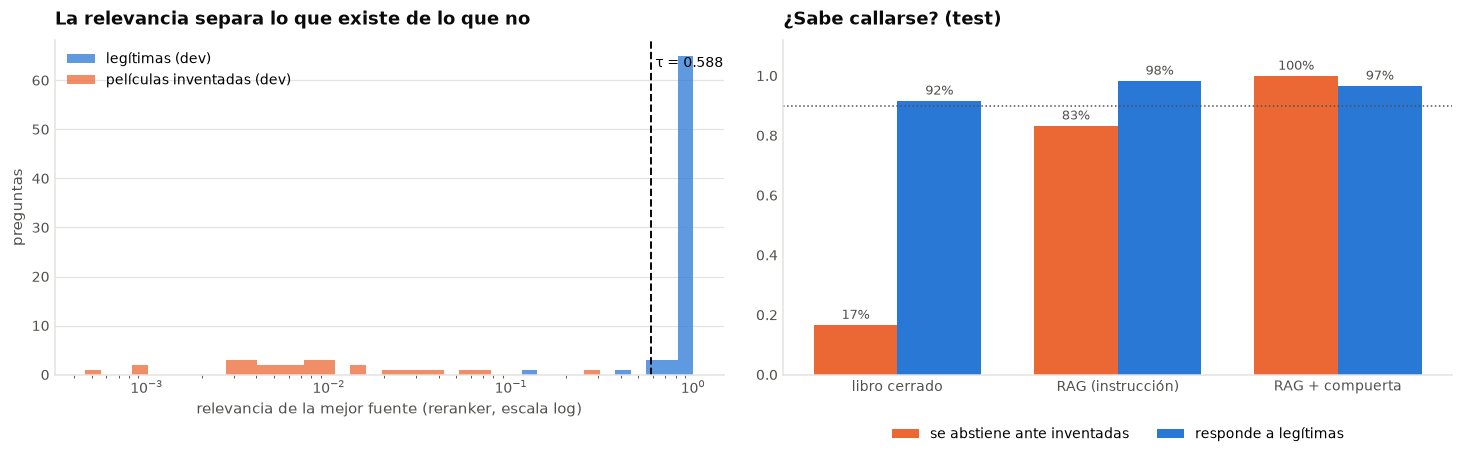

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 4.3))
bins = np.logspace(np.log10(max(1e-5, min(s_legit.min(), s_falsas.min()))), 0, 40)
ax1.hist(s_legit, bins=bins, color=AZUL, alpha=.75, label="legítimas (dev)")
ax1.hist(s_falsas, bins=bins, color=NARANJA, alpha=.75, label="películas inventadas (dev)")
ax1.axvline(TAU, color=TINTA, ls="--", lw=1.3)
ax1.text(TAU, ax1.get_ylim()[1] * .95, f" τ = {TAU:.3f}", fontsize=9, va="top")
ax1.set_xscale("log"); ax1.set_xlabel("relevancia de la mejor fuente (reranker, escala log)")
ax1.set_ylabel("preguntas"); ax1.set_title("La relevancia separa lo que existe de lo que no")
ax1.legend(loc="upper left"); ax1.grid(axis="y"); ax1.set_axisbelow(True); limpiar(ax1)

x = np.arange(len(res_abst))
ax2.bar(x - .19, res_abst["se abstiene ante inventadas"], width=.38, color=NARANJA, label="se abstiene ante inventadas")
ax2.bar(x + .19, res_abst["responde a legítimas"], width=.38, color=AZUL, label="responde a legítimas")
for i, (a, b) in enumerate(res_abst.values):
    ax2.text(i - .19, a + .02, f"{a:.0%}", ha="center", fontsize=8.5, color=TINTA_2)
    ax2.text(i + .19, b + .02, f"{b:.0%}", ha="center", fontsize=8.5, color=TINTA_2)
ax2.axhline(.9, color=TINTA_2, ls=":", lw=1)
ax2.set_xticks(x); ax2.set_xticklabels(res_abst.index); ax2.set_ylim(0, 1.12)
ax2.set_title("¿Sabe callarse? (test)")
ax2.legend(loc="upper center", bbox_to_anchor=(.5, -.12), ncol=2); limpiar(ax2)
plt.tight_layout(); guardar(fig, "09-abstencion"); plt.show()

**Lo que vimos.** La relevancia del reranker separa casi a la perfección lo que existe de lo que no: la
mejor fuente de una pregunta legítima de trama tiene una relevancia mediana de 0,99 y la de una película
inventada, de 0,007. Con la regla del 95 %, τ = 0,59, y en dev la compuerta bloquea todas las inventadas.

En test, las tres condiciones cuentan tres historias:

- **A libro cerrado, el modelo casi nunca se calla.** El 77 % de sus respuestas a películas inventadas
  *empieza* diciendo que no tiene información, pero sólo el 17 % se detiene ahí. El resto sigue con *"Sin
  embargo, puedo proporcionarte algunos datos generales…"* y se inventa una novela de Juan Gabriel
  Vásquez o una serie colombiana. Otras ni dudan: *"¡Claro que vale la pena! La Isla de los Relojes del
  Pacífico es un lugar emblemático…"*. A las 30 preguntas de trama, a libro cerrado no identifica
  **ninguna** película; CineRAG, el 93 %.
- **La instrucción del *prompt* funciona mejor de lo que esperábamos**: CineRAG sin compuerta se
  abstiene ante el 83 % de las inventadas. Pero el 17 % restante es justo el fallo más dañino de un RAG.
  El modelo recibe críticas de *Infierno en el Pacífico* o de *Kong: La isla calavera* y las presenta como
  opiniones sobre *La isla de los relojes del Pacífico*. Cita fuentes reales para una película que no
  existe.
- **La compuerta cierra ese hueco**: 100 % de abstención ante las inventadas, y sigue respondiendo al
  97 % de las legítimas. El 3 % que no responde son preguntas de trama vagas que no superan τ.

H6 queda a medias por su primera mitad: la instrucción sola no se quedó por debajo del 50 %. La
conclusión práctica no cambia. La instrucción reduce el problema y la compuerta lo elimina, sin
gastar una llamada al LLM.

### 8.4 ¿Las citas se pueden verificar?

Sobre las 60 respuestas de CineRAG a preguntas legítimas de §8.3 (sin compuerta): qué parte cita al menos
una fuente, qué parte cita dentro del texto y no sólo al final, qué parte de las citas apunta a una fuente
que existe y qué parte de lo citado es **de la película preguntada**. Al final, la latencia medida en vivo. Una cita a una crítica de otra película es la
versión RAG de una alucinación.

In [37]:
reales = abst[leg & ~abst.abst_rag].copy()
reales["con_cita"] = reales.citas.map(len) > 0
reales["citas_validas"] = [np.mean([1 <= n <= len(fs) for n in c]) if c else np.nan
                           for c, fs in zip(reales.citas, reales.fuentes)]
reales["citas_de_la_pelicula"] = [np.mean([fs[n - 1] == f for n in c if 1 <= n <= len(fs)])
                                  if (c and isinstance(f, str) and any(1 <= n <= len(fs) for n in c)) else np.nan
                                  for c, fs, f in zip(reales.citas, reales.fuentes, reales.film_id)]
reales["n_citas"] = reales.citas.map(len)
reales["cita_en_el_texto"] = reales.respuesta_rag.map(cita_en_cuerpo)
CITAS = reales.groupby("familia")[["con_cita", "cita_en_el_texto", "n_citas", "citas_validas",
                                   "citas_de_la_pelicula"]].mean()
print(f"respuestas legítimas en las que CineRAG no se abstuvo: {len(reales)} de {leg.sum()}\n")
print(CITAS.round(2).to_string())
# Latencia medida en vivo, sin la memoria en disco, sobre diez preguntas de opinión de test.
llm.stats.clear()
vivo = CineRAG(rec_final, llm)
for q in test[test.familia == "opinion"].pregunta.head(10):
    vivo(q, guardar=False, memo=False)
st = pd.DataFrame(llm.stats)
print(f"\nlatencia en vivo ({len(st)} respuestas, {DEVICE}): mediana {st.segundos.median():.1f} s por respuesta · "
      f"prompt {st.tokens_prompt.median():.0f} tokens · respuesta {st.tokens_salida.median():.0f} tokens · "
      f"generación {(st.tokens_salida / st.seg_generacion).median():.0f} tokens/s")

respuestas legítimas en las que CineRAG no se abstuvo: 59 de 60

         con_cita  cita_en_el_texto  n_citas  citas_validas  citas_de_la_pelicula
familia                                                                          
opinion      1.00              0.17     3.57            1.0                  1.00
trama        0.97              0.55     2.10            1.0                  0.89



latencia en vivo (10 respuestas, cuda): mediana 1.9 s por respuesta · prompt 1291 tokens · respuesta 173 tokens · generación 103 tokens/s


**Lo que vimos.** De las 60 preguntas legítimas, CineRAG respondió 59. Cita alguna fuente en el 100 % de
las respuestas de opinión y en el 97 % de las de trama. **Todas las citas apuntan a fuentes que
existen**, y en opinión el 100 % de lo citado es de la película preguntada. En trama baja al 89 %, porque
a veces cita una segunda película candidata, lo que en una pregunta de descubrimiento es razonable.

Lo que no conseguimos del todo es que cite frase a frase. Con la regla elegida, sólo el 17 % de las
respuestas de opinión tiene alguna cita dentro del texto (55 % en trama); el resto las pone en bloque al
final. Las citas son verificables, pero hay que abrir la crítica para saber qué frase respalda cada una.
La prueba de §8.1 muestra que es un límite del modelo más que de la redacción. La mejor de las tres
redacciones (B) cita dentro del texto en el 42 % de las 38 preguntas. La C, que había ganado en una
prueba piloto con 8 preguntas, baja con 38 al 82 % de respuestas con alguna cita: con pocas preguntas
habíamos elegido mal.

Latencia en vivo: 1,9 s por respuesta, con un *prompt* de unos 1.300 tokens (seis fuentes) y respuestas
de unos 170 tokens a 100 tokens/s en una RTX 5050 de portátil. La recuperación y el reranker suman
decenas de milisegundos: la sensación es la de un chat normal.

---

## 9. CineRAG

### 9.1 Demo en el notebook: una conversación con memoria

Lo mismo que se verá en la interfaz, en texto: una pregunta de opinión, una de seguimiento que sólo se
entiende con la anterior, una de trama y una sobre una película que no existe. Debajo de cada respuesta,
la pregunta tal como la reescribió la memoria, lo que decidió el router y las fuentes citadas.

In [38]:
bot = CineRAG(rec_final, llm, umbral=TAU)

def conversar(preguntas):
    for q in preguntas:
        e = bot(q)
        f = e["filtros"]
        peli = P.loc[f["film_ids"][0]].film_title if f["film_ids"] else "—"
        notas = RANGO.get(f["notas"], "todas")
        print(f"🧑 {q}")
        if e["consulta"] != q:
            print(f"   ↳ reescrita: {e['consulta']}")
        print(f"   ↳ router: película {peli} · notas {notas} · spoilers {'sí' if f['spoilers'] else 'no'}"
              + (f" · compuerta (relevancia {e['tope']:.3f} < τ)" if e["compuerta"] else ""))
        print(f"🤖 {con_fuentes(e)}\n")

with medir("§9.1 demo"):
    conversar(["¿Qué opinan los espectadores de Oppenheimer?",
               "¿Y qué le critican los que le pusieron mala nota?"])
    bot.reset()
    conversar(["Busco una película de supervivencia en la nieve basada en hechos reales"])
    bot.reset()
    conversar(["¿Qué tal es El relojero de Mompox?"])
guardar_memo()

🧑 ¿Qué opinan los espectadores de Oppenheimer?
   ↳ router: película Oppenheimer · notas todas · spoilers no
🤖 Los espectadores de Oppenheimer tienen opiniones muy variadas sobre la película. Algunos, como el usuario que le dio una nota de 5/10, critican la falta de profundidad en la trama política y la simplificación de los aspectos técnicos del desarrollo de la bomba atómica. Otros, como el usuario que le dio una nota de 8/10, elogian la dirección magistral de Christopher Nolan y la actuación de Cillian Murphy como J. Robert Oppenheimer, que logra transmitir la complejidad interna del personaje. Un usuario más crítico, con una nota de 4/10, considera que la película es un espectáculo palomitero que no logra construir una narrativa sólida, aunque reconoce que las actuaciones son buenas. Finalmente, un usuario que le dio una nota de 9/10 considera que la película es una representación compleja y fascinante del personaje de Oppenheimer, que trasciende fronteras y puede ejercer como fuer

🧑 ¿Qué tal es El relojero de Mompox?
   ↳ router: película — · notas todas · spoilers no · compuerta (relevancia 0.001 < τ)
🤖 No tengo críticas sobre eso en mi catálogo.

*(Lo más cercano en el catálogo era «El elemento del crimen», con relevancia 0.00.)*

   ⏱  §9.1 demo: 0.0 min   (acumulado 1.4 min)


**Lo que vimos.** Las piezas que no se ven en las métricas, funcionando juntas:

- La primera respuesta resume cuatro críticas con notas 4, 5, 8 y 9 y las atribuye (*"un usuario más
  crítico, con una nota de 4/10…"*). No da "la opinión": da opiniones.
- La pregunta de seguimiento no nombra la película. La memoria la reescribe (*"¿Qué le critican los
  espectadores que le dieron una puntuación baja en Oppenheimer?"*), el router aplica el filtro de notas
  1–4 y las tres fuentes citadas tienen 1, 4 y 4.
- La pregunta de trama no nombra ninguna película y encuentra *¡Viven!*, con su ficha [1] y una crítica
  [2], cada una citada después de la frase que respalda.
- La película inventada no llega al LLM: la compuerta responde sola, porque la mejor relevancia del
  catálogo es 0,001.

Lo que sigue sin resolver se ve también: en las respuestas de opinión las citas se amontonan al final
del párrafo (§8.4).

### 9.2 La interfaz

La interfaz del guía (un `gr.Chatbot` y una caja de texto) con tres añadidos:

- **Respuesta en *streaming***, token a token, como en ChatGPT.
- **Panel de fuentes**: la pregunta tal como la reescribió la memoria, lo que decidió el router y las
  fuentes recuperadas con su relevancia. Así se ve *por qué* el bot responde lo que responde.
- **Ajustes de recuperación**, para repetir en vivo los experimentos de §6: número de fuentes, tipo de
  búsqueda, reranker, diversidad (una fuente por crítica + MMR), *spoilers* y filtro de nota.

La memoria vive en el objeto `bot_app` y se borra con *Nueva conversación*. En Colab, `share=True`
crea un enlace público temporal.

In [39]:
import gradio as gr

bot_app = CineRAG(rec_final, llm, umbral=TAU)
OPC_NOTA = {"automático (router)": "auto", "todas": None, "negativas (1-4)": NEG,
            "intermedias (5-6)": MED, "positivas (7-10)": POS}
EJEMPLOS = ["¿Qué opinan los espectadores de Oppenheimer?",
            "¿Y qué le critican los que le pusieron mala nota?",
            "Busco una película de supervivencia en la nieve basada en hechos reales",
            "¿Qué dicen de la banda sonora de Interstellar?",
            "¿Quién dirigió Parásitos y dónde la puedo ver?",
            "¿Qué tal es El relojero de Mompox?"]
VACIO = "Las fuentes de cada respuesta aparecerán aquí."

def panel(e):
    f = e["filtros"]
    peli = ", ".join(P.loc[x].film_title for x in f["film_ids"]) if f["film_ids"] else "ninguna"
    notas = RANGO.get(f["notas"], "todas")
    lineas = [f"**Consulta usada:** {e['consulta']}",
              f"**Router:** película → *{peli}* · notas → {notas} · "
              f"spoilers → {'permitidos' if f['spoilers'] else 'excluidos'}"]
    if e["compuerta"]:
        lineas.append(f"**Compuerta:** relevancia máxima {e['tope']:.3f} < τ = {TAU:.3f} → no se llama al LLM")
    lineas += ["", "| # | fuente | nota | relevancia | fragmento |", "|---|---|---|---|---|"]
    for n, d in enumerate(e["fuentes"].itertuples(), 1):
        p = P.loc[d.film_id]
        nota = "" if d.tipo == "ficha" else f"{int(d.nota)}/10"
        rel = f"{d.relevancia:.3f}" if hasattr(d, "relevancia") else "–"
        frag = d.cuerpo[:150].replace("|", "/").replace("\n", " ")
        lineas.append(f"| {n} | {d.tipo} · {p.film_title} ({p.film_year}) | {nota} | {rel} | {frag}… |")
    return "\n".join(lineas)

def responder(pregunta, historial, k, modo, rerank, usar_mmr, spoilers, nota):
    historial = list(historial or [])
    if not pregunta.strip():
        yield "", historial, VACIO
        return
    historial += [{"role": "user", "content": pregunta}, {"role": "assistant", "content": "…"}]
    opciones = dict(k=int(k), modo=modo, rerank=rerank, mmr=MMR_LAMBDA if usar_mmr else None,
                    por_critica=usar_mmr, notas=OPC_NOTA[nota], spoilers=True if spoilers else None)
    for texto, e in bot_app.responder_stream(pregunta, **opciones):
        historial[-1] = {"role": "assistant", "content": texto}
        yield "", historial, panel(e)

def nueva():
    bot_app.reset()
    return "", [], VACIO

with gr.Blocks(title="CineRAG") as demo:
    gr.Markdown(f"# 🎬 CineRAG · pregúntale a FilmAffinity\n"
                f"Responde con **{len(catalogo)} películas** y **{len(resenas):,} críticas de usuarios**, "
                f"y cita cada afirmación. Generador `{MODELO_LLM}` (Ollama) · búsqueda híbrida BM25 + "
                f"`{ENCODERS[ENCODER_FINAL].split('/')[-1]}` · reranker `{RERANKER.split('/')[-1]}`.")
    with gr.Row():
        with gr.Column(scale=3):
            chat = gr.Chatbot(height=520, label="Conversación")
            msg = gr.Textbox(label="Tu pregunta", placeholder="¿Qué opinan los espectadores de Oppenheimer?")
            with gr.Row():
                enviar = gr.Button("Preguntar", variant="primary")
                borrar = gr.Button("Nueva conversación")
            gr.Examples(EJEMPLOS, inputs=msg, label="Ejemplos")
        with gr.Column(scale=2):
            with gr.Accordion("Ajustes de recuperación", open=False):
                k = gr.Slider(3, 10, value=6, step=1, label="Número de fuentes (k)")
                modo = gr.Radio(["hibrido", "denso", "bm25"], value="hibrido", label="Búsqueda")
                rerank = gr.Checkbox(True, label="Reranker (cross-encoder)")
                usar_mmr = gr.Checkbox(True, label=f"Diversificar fuentes (una por crítica + MMR, λ = {MMR_LAMBDA})")
                spoilers = gr.Checkbox(False, label="Permitir spoilers")
                nota = gr.Radio(list(OPC_NOTA), value="automático (router)", label="Filtro de nota")
            fuentes = gr.Markdown(VACIO)
    entradas = [msg, chat, k, modo, rerank, usar_mmr, spoilers, nota]
    msg.submit(responder, entradas, [msg, chat, fuentes])
    enviar.click(responder, entradas, [msg, chat, fuentes])
    borrar.click(nueva, None, [msg, chat, fuentes], queue=False)

demo.launch(share=IN_COLAB, inline=False, prevent_thread_lock=True)

* Running on local URL:  http://127.0.0.1:7860


* To create a public link, set `share=True` in `launch()`.


#### ¡Atención!
Abre el enlace que imprime la celda de arriba en otra pestaña. Cuando termines, descomenta y ejecuta la
celda siguiente para cerrar el servidor.

In [40]:
# demo.close()

---

## 10. Costes, veredicto y conclusiones

### 10.1 Lo que costó

In [41]:
crono = pd.DataFrame(CRONO).groupby("paso", sort=False).segundos.sum()
print("esta corrida (lo que estaba en cache/ no se repite):")
print((crono / 60).round(2).rename("minutos").to_string())
if TIEMPOS_EMB:
    print("\nembeddings, la primera vez que se calcularon:")
    print((pd.Series(TIEMPOS_EMB) / 60).round(2).rename("minutos").to_string())

esta corrida (lo que estaba en cache/ no se repite):
paso
calentar el LLM                        0.01
evaluación: troceado (dev)             0.29
evaluación: encoder (dev)              0.31
evaluación: diversidad (dev)           0.11
evaluación: escalera (test)            0.36
§8.1 redacción de la regla de citas    0.07
§8.2 directores: 4 condiciones         0.12
§8.3 umbral de la compuerta (dev)      0.06
§8.3 abstención (test)                 0.05
§9.1 demo                              0.00

embeddings, la primera vez que se calcularon:
large-palabras-sincab-sinpref-34836    3.69
large-palabras-cab-pref-34836          4.63
large-oraciones-cab-pref-29858         3.48
large-resena-cab-pref-7798             1.94
small-palabras-cab-pref-34836          1.07
base-palabras-cab-pref-34836           2.21
base-oraciones-cab-pref-29858          1.40
large-palabras-sincab-pref-34836       3.94


### 10.2 Veredicto de las hipótesis

La celda calcula cada veredicto a partir de las variables y del criterio escrito en §1.6. Puede salir en
contra.

In [42]:
from IPython.display import display

ESTADO = {2: "✔ se sostiene", 1: "◐ parcial", 0: "✘ refutada"}
# Las comparaciones se hacen con 3 decimales: en coma flotante, 0,35 − 0,10 = 0,2499…
V = []
def fila(h, criterio, medido, estado):
    V.append({"hipótesis": h, "criterio": criterio, "medido": medido, "veredicto": ESTADO[int(estado)]})

saltos_op = {n: SALTOS[(n, "opinion")][0] for n in PELDANOS[1:]}
d_cab = round(saltos_op["L2 · + cabecera"], 3)
fila("H1 · la cabecera es el escalón más grande", "opinión: ΔP@5 ≥ 0,20 y el mayor salto de la escalera",
     f"ΔP@5 = {d_cab:+.3f}; mayor salto: {max(saltos_op, key=saltos_op.get)}",
     int(d_cab >= 0.20) + int(max(saltos_op, key=saltos_op.get) == "L2 · + cabecera"))

sig = [SALTOS[("L1 · + prefijos E5", f)] for f in FAMILIAS]
n_sig = sum(d > 2 * sd for d, sd in sig)
fila("H2 · los prefijos de E5 importan", "mejora > 2 desviaciones en ≥ 2 de 3 familias",
     "; ".join(f"{f} {d:+.3f} ± {sd:.3f}" for f, (d, sd) in zip(FAMILIAS, sig)),
     2 if n_sig >= 2 else int(n_sig))

s = resumir(ev_test).set_index(["config", "familia"]).media
gana = [f for f in FAMILIAS if s[("L3 · + BM25 (híbrida)", f)] > max(s[("L2 · + cabecera", f)], s[(BM25_SOLO, f)])]
d_rr, sd_rr = SALTOS[("L4 · + reranker", "aspecto")]
fila("H3 · léxico y semántico se complementan",
     "híbrida > mejor de sus partes en ≥ 2 familias; reranker > 2 desv. en aspecto",
     f"híbrida gana en {len(gana)}/3 ({', '.join(gana) or '—'}); reranker en aspecto {d_rr:+.3f} ± {sd_rr:.3f}",
     int(len(gana) >= 2) + int(d_rr > 2 * sd_rr))

cer = dirs[(dirs.modelo == "3B") & (dirs.condicion == "libro cerrado")]
rag = dirs[(dirs.modelo == "3B") & (dirs.condicion == "RAG")]
acc_c = round(cer.acierto.mean(), 3)
brecha = round(cer[cer.quintil == 5].acierto.mean() - cer[cer.quintil == 1].acierto.mean(), 3)
min_rag = round(rag.groupby("quintil").acierto.mean().min(), 3)
c4 = [acc_c < 0.5, brecha >= 0.25, min_rag >= 0.85]
fila("H4 · sin RAG inventa, y más en la cola larga",
     "libro cerrado < 0,50; q5 − q1 ≥ 0,25; con RAG ≥ 0,85 en cada quintil",
     f"libro cerrado {acc_c:.2f}; q5 − q1 = {brecha:+.2f}; RAG, peor quintil {min_rag:.2f}",
     2 if all(c4) else int(any(c4)))

acc = dirs.groupby(["modelo", "condicion"]).acierto.mean()
g_c = acc[("3B", "libro cerrado")] - acc[("1B", "libro cerrado")]
g_r = acc[("3B", "RAG")] - acc[("1B", "RAG")]
fila("H5 · con RAG el tamaño importa menos", "brecha 3B − 1B con RAG < mitad de la brecha a libro cerrado",
     f"libro cerrado {g_c:+.2f}; RAG {g_r:+.2f}", 2 if (g_c > 0 and g_r < g_c / 2) else 0)

inv_rag, leg_rag = res_abst.loc["RAG (instrucción)"]
inv_cmp, leg_cmp = res_abst.loc["RAG + compuerta"]
c6 = [inv_rag < 0.5, inv_cmp >= 0.9 and leg_cmp >= 0.9]
fila("H6 · una instrucción no basta; una compuerta sí",
     "RAG con instrucción < 0,50 de abstención; con compuerta ≥ 0,90 y responde ≥ 0,90",
     f"instrucción {inv_rag:.2f}; compuerta {inv_cmp:.2f} (responde a legítimas {leg_cmp:.2f})",
     2 if all(c6) else int(any(c6)))

veredicto = pd.DataFrame(V)
veredicto.to_csv(RES / f"veredicto{SUFIJO}.csv", index=False)
with pd.option_context("display.max_colwidth", None):
    display(veredicto)

,hipótesis,criterio,medido,veredicto
0,H1 · la cabecera es el escalón más grande,"opinión: ΔP@5 ≥ 0,20 y el mayor salto de la escalera",ΔP@5 = +0.147; mayor salto: L2 · + cabecera,◐ parcial
1,H2 · los prefijos de E5 importan,mejora > 2 desviaciones en ≥ 2 de 3 familias,opinion +0.040 ± 0.014; trama +0.045 ± 0.034; aspecto -0.003 ± 0.018,◐ parcial
2,H3 · léxico y semántico se complementan,híbrida > mejor de sus partes en ≥ 2 familias; reranker > 2 desv. en aspecto,híbrida gana en 1/3 (aspecto); reranker en aspecto +0.013 ± 0.043,✘ refutada
3,"H4 · sin RAG inventa, y más en la cola larga","libro cerrado < 0,50; q5 − q1 ≥ 0,25; con RAG ≥ 0,85 en cada quintil","libro cerrado 0.24; q5 − q1 = +0.25; RAG, peor quintil 1.00",✔ se sostiene
4,H5 · con RAG el tamaño importa menos,brecha 3B − 1B con RAG < mitad de la brecha a libro cerrado,libro cerrado +0.19; RAG +0.01,✔ se sostiene
5,H6 · una instrucción no basta; una compuerta sí,"RAG con instrucción < 0,50 de abstención; con compuerta ≥ 0,90 y responde ≥ 0,90",instrucción 0.83; compuerta 1.00 (responde a legítimas 0.97),◐ parcial


### 10.3 Conclusiones

Corrimos el notebook completo en local (RTX 5050 de 8 GB): unos 47 minutos la primera vez y 3 minutos
con la caché. Lo decimos de entrada: **un RAG bien medido convierte a un modelo de 3B que inventa la
mitad de las fichas en uno que las acierta todas y que sabe callarse**. Pero las piezas que más pesan
no son las que esperábamos. Dos hipótesis se sostienen, tres quedan parciales y una se refuta.

1. **¿Qué pieza importa más?** (H1 · parcial, figuras 06–07)
   Depende de la pregunta. En opinión, la cabecera contextual: +0,15 de P@5, que la lleva a 1,00. Es el
   mayor salto de esa familia, pero no llegó al +0,20 que pedimos, porque la réplica del guía ya
   acertaba 0,81 gracias a las fichas, que sí llevan el título. El EDA dio la razón de fondo: el 60 % de
   las críticas no nombra su película. En t-SNE, la silueta por película pasa de 0,08 a 0,53. Una línea
   de metadatos delante de cada fragmento, sin entrenar nada, es la mejora más barata del notebook.

2. **¿El guía pierde por no usar los prefijos de E5?** (H2 · parcial)
   Un poco: +0,04 en opinión, significativo; +0,045 en trama, sin llegar a serlo; nada en aspecto.
   Ponerlos no cuesta nada, pero no es ahí donde está la ganancia.

3. **¿Léxico y semántico se complementan?** (H3 · refutada)
   No como esperábamos. BM25 solo le gana a la híbrida en trama (0,86 frente a 0,81), y la fusión RRF
   sólo supera a sus dos partes en aspecto. Quien combina bien las dos señales es el reranker (+0,12 en
   trama), que en cambio no ayudó donde lo esperábamos (aspecto, +0,01). La lección: la fusión por
   rangos con pesos iguales no es un combinador neutro cuando una de las listas es mucho peor que la
   otra.

4. **¿Sin RAG inventa?** (H4 · se sostiene, figura 08)
   Sí. A libro cerrado, el 3B acierta el director en el 24 % de las películas e inventa en el 51 %, y
   falla más en la cola larga (10 % de acierto en el quintil menos popular, 35 % en el más popular). Con
   RAG acierta el 100 % en todos los quintiles.

5. **¿Con RAG basta un modelo más pequeño?** (H5 · se sostiene)
   Para responder con datos de la ficha, sí. El 1B pasa del 5 % al 99 %, y la brecha con el 3B se reduce
   de 19 puntos a uno. El conocimiento lo pone el recuperador; el generador sólo tiene que copiar bien.

6. **¿Sabe callarse?** (H6 · parcial, figura 09)
   A libro cerrado, no: empieza diciendo "no tengo información" y sigue inventando. Con RAG, la
   instrucción ya consigue un 83 % de abstención, más de lo que esperábamos. El 17 % restante es el fallo
   más grave que vimos: citar críticas reales de otra película como si fueran de una que no existe. La
   compuerta del reranker lo lleva al 100 % sin dejar de responder al 97 % de las preguntas legítimas, y
   sin llamar al LLM.

**Lo que no estaba en las hipótesis y aprendimos leyendo respuestas.** Cuatro fallos aparecieron sólo
al leer lo que contestaba el chatbot, y cada uno acabó siendo una pieza del sistema. Un filtro de nota
que deja sólo la ficha hace que el modelo se invente la crítica que falta: esa salida ya no pasa por el
LLM. Una memoria que lee las respuestas anteriores pierde la película: el router tiene ahora su propia
memoria. Un ejemplo con contenido en el *prompt* se cuela en las respuestas: el ejemplo de la regla de
citas está vacío. Y sin tope de tokens, `llama3.2:3b` generó 80.000 en bucle: ahora hay un límite de
512. Las métricas de recuperación no habrían detectado ninguno de los cuatro.

**Lo más grande no siempre fue lo mejor.** `e5-base` superó a `e5-large`, el del guía, con la mitad de
coste, y el troceado resultó casi irrelevante una vez que la búsqueda es completa. Son decisiones que
hay que medir en cada caso.

**Las críticas más útiles son más negativas.** Seleccionar las más votadas como útiles deja una nota
media 0,6 puntos más baja que la del conjunto. CineRAG lo compensa a medias: la ficha, con la nota media
de FilmAffinity, entra siempre entre las fuentes, pero el modelo no siempre la usa.

**Volviendo a la Sesión 4.** Allí intentamos que un GPT-2 afinado escribiera la crítica que se le
pedía, y no obedeció. Aquí no le enseñamos nada al modelo y obedece: responde con la película, la nota y
el aspecto que se le piden, porque se los damos a leer. Para un dominio de opiniones que cambia todos
los días, y con modelos pequeños, es la mejor apuesta, con un matiz que esta entrega deja claro: la
calidad sale de la recuperación y de las salvaguardas que rodean al LLM, más que del LLM mismo.

### 10.4 Limitaciones y trabajo futuro

- **El banco es sintético.** Lo genera el mismo LLM que responde, y las preguntas de aspecto a veces son
  genéricas. Un banco escrito por personas, aunque fuera de 50 preguntas, validaría las cifras.
- **La fidelidad de los resúmenes no se mide.** Contamos lo que se puede contar (acierto de ficha,
  abstención, citas válidas y de la película correcta), pero no si el resumen de opiniones es fiel a las
  críticas. El paso siguiente sería un juez: otro LLM, o el BETO de la Sesión 3 comprobando que la
  respuesta conserva el signo de las críticas que cita.
- **Citar frase a frase.** El modelo de 3B cita bien pero en bloque. Un modelo de 7–8B, o pedirle una
  salida estructurada (frase y fuente), probablemente lo resolvería.
- **Escala.** Son 500 películas y 12 críticas por película. Con el corpus completo, unos 2 millones de
  fragmentos, el índice exacto deja de servir (§6.7), y el router por reglas tendría que desambiguar
  títulos repetidos y tolerar erratas. La alternativa natural es un router por LLM con salida JSON.
- **Un solo umbral para la compuerta.** τ se eligió con preguntas de trama y bloquea el 3 % de las
  legítimas más vagas. Un umbral por tipo de pregunta, o una respuesta intermedia (*"¿te refieres a…?"*),
  sería más amable.
- **El sesgo de las críticas útiles.** Estratificar por nota al seleccionarlas haría que el catálogo
  reprodujera la distribución real de cada película.

### Referencias

- Lewis, P. *et al.* (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS. [arXiv:2005.11401](http://arxiv.org/abs/2005.11401)
- Wang, L. *et al.* (2022). *Text Embeddings by Weakly-Supervised Contrastive Pre-training* (E5). [arXiv:2212.03533](https://arxiv.org/abs/2212.03533) · [ficha de `multilingual-e5-large`](https://huggingface.co/intfloat/multilingual-e5-large)
- Robertson, S. y Zaragoza, H. (2009). *The Probabilistic Relevance Framework: BM25 and Beyond*. Foundations and Trends in IR.
- Cormack, G., Clarke, C. y Büttcher, S. (2009). *Reciprocal Rank Fusion outperforms Condorcet and individual rank learning methods*. SIGIR.
- Chen, J. *et al.* (2024). *BGE M3-Embedding*. [arXiv:2402.03216](https://arxiv.org/abs/2402.03216) · [`bge-reranker-v2-m3`](https://huggingface.co/BAAI/bge-reranker-v2-m3)
- Carbonell, J. y Goldstein, J. (1998). *The Use of MMR, Diversity-Based Reranking for Reordering Documents and Producing Summaries*. SIGIR.
- Malkov, Y. y Yashunin, D. (2018). *Efficient and robust approximate nearest neighbor search using Hierarchical Navigable Small World graphs*. [arXiv:1603.09320](https://arxiv.org/abs/1603.09320)
- Anthropic (2024). *Introducing Contextual Retrieval*. [anthropic.com/news/contextual-retrieval](https://www.anthropic.com/news/contextual-retrieval)
- Es, S. *et al.* (2023). *RAGAS: Automated Evaluation of Retrieval Augmented Generation*. [arXiv:2309.15217](https://arxiv.org/abs/2309.15217)
- Bruno, A. *et al.* (2023). *Insights into Classifying and Mitigating LLMs' Hallucinations*. (citado en la clase teórica)
- Meta (2024). *Llama 3.2 model card*. [ollama.com/library/llama3.2](https://ollama.com/library/llama3.2)
- Dataset: [`naim-prog/filmaffinity-reviews-info`](https://huggingface.co/datasets/naim-prog/filmaffinity-reviews-info) (MIT).
- Notebooks guía de la sesión: [`Ohtar10/icesi-nlp/Sesion5`](https://github.com/Ohtar10/icesi-nlp/tree/main/Sesion5).